In [ ]:
# ==========================================
# CELL 1: CÀI ĐẶT MÔI TRƯỜNG VÀ TẢI SOFTS
# ==========================================
!git clone https://github.com/Secilia-Cxy/SOFTS.git
%cd /content/SOFTS
!pip -q install scikit-learn pandas numpy matplotlib

from pathlib import Path

# Vá lỗi tương thích cú pháp của Pandas và Numpy trong mã nguồn SOFTS gốc
p = Path("data_provider/data_loader.py")
p.write_text(p.read_text().replace("drop(['date'], 1)", "drop(['date'], axis=1)"))

p = Path("utils/tools.py")
p.write_text(p.read_text().replace("np.Inf", "np.inf"))

print("✅ Tải mã nguồn và thiết lập môi trường thành công!")

Cloning into 'SOFTS'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 167 (delta 26), reused 16 (delta 16), pack-reused 132 (from 2)
Receiving objects: 100% (167/167), 3.34 MiB | 40.69 MiB/s, done.
Resolving deltas: 100% (71/71), done.
/content/SOFTS
✅ Tải mã nguồn và thiết lập môi trường thành công!


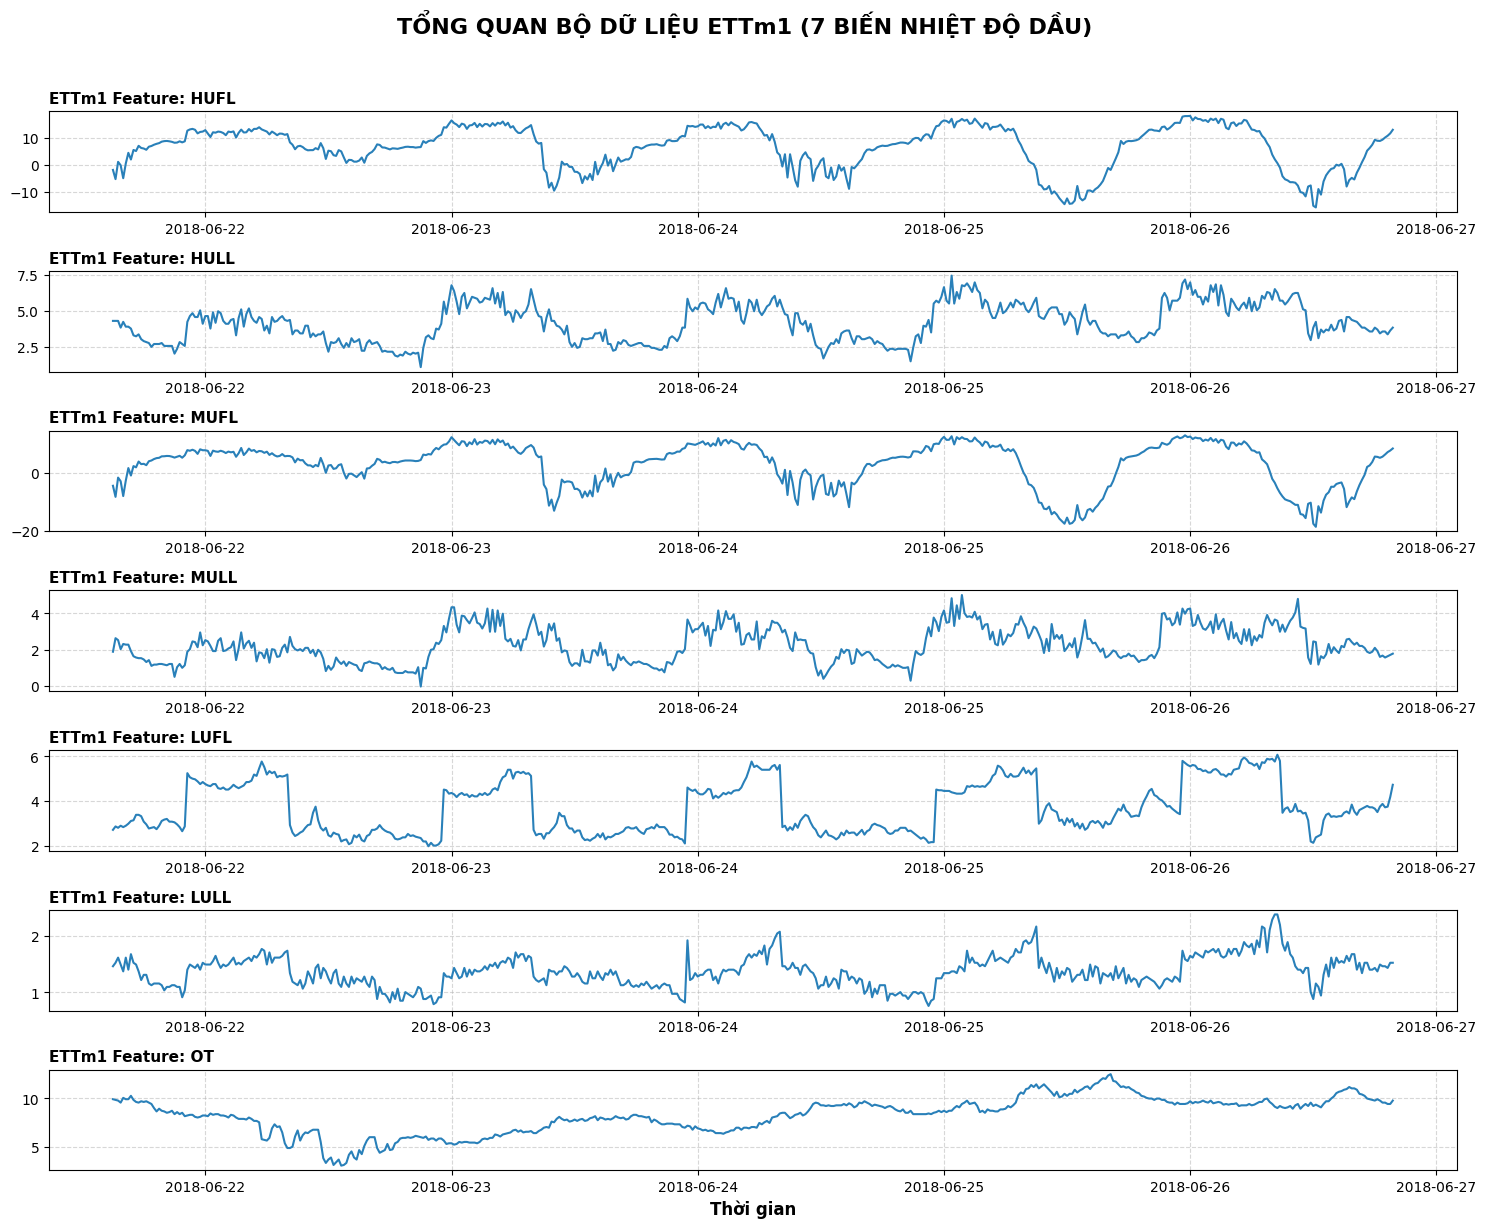

In [ ]:
# ==========================================
# CELL 2: TRỰC QUAN DỮ LIỆU BAN ĐẦU (ETTm1)
# ==========================================
!mkdir -p ./dataset/ETT-small
!wget -q -O ./dataset/ETT-small/ETTm1.csv https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm1.csv

import pandas as pd
import matplotlib.pyplot as plt

df_ett = pd.read_csv('./dataset/ETT-small/ETTm1.csv')
if 'date' in df_ett.columns:
    df_ett['date'] = pd.to_datetime(df_ett['date'])
    df_ett.set_index('date', inplace=True)

# Lấy 500 giờ cuối để nhìn rõ sự biến động
df_plot_ett = df_ett.iloc[-500:]

plt.figure(figsize=(15, 12))
for i, col in enumerate(df_ett.columns):
    plt.subplot(7, 1, i+1)
    plt.plot(df_plot_ett.index, df_plot_ett[col], color='#2980b9', linewidth=1.5)
    plt.title(f"ETTm1 Feature: {col}", loc='left', fontweight='bold', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Thời gian', fontsize=12, fontweight='bold')
plt.suptitle('TỔNG QUAN BỘ DỮ LIỆU ETTm1 (7 BIẾN NHIỆT ĐỘ DẦU)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

✅ Đã tìm thấy dữ liệu Hà Nội. Đang tiến hành vẽ biểu đồ...


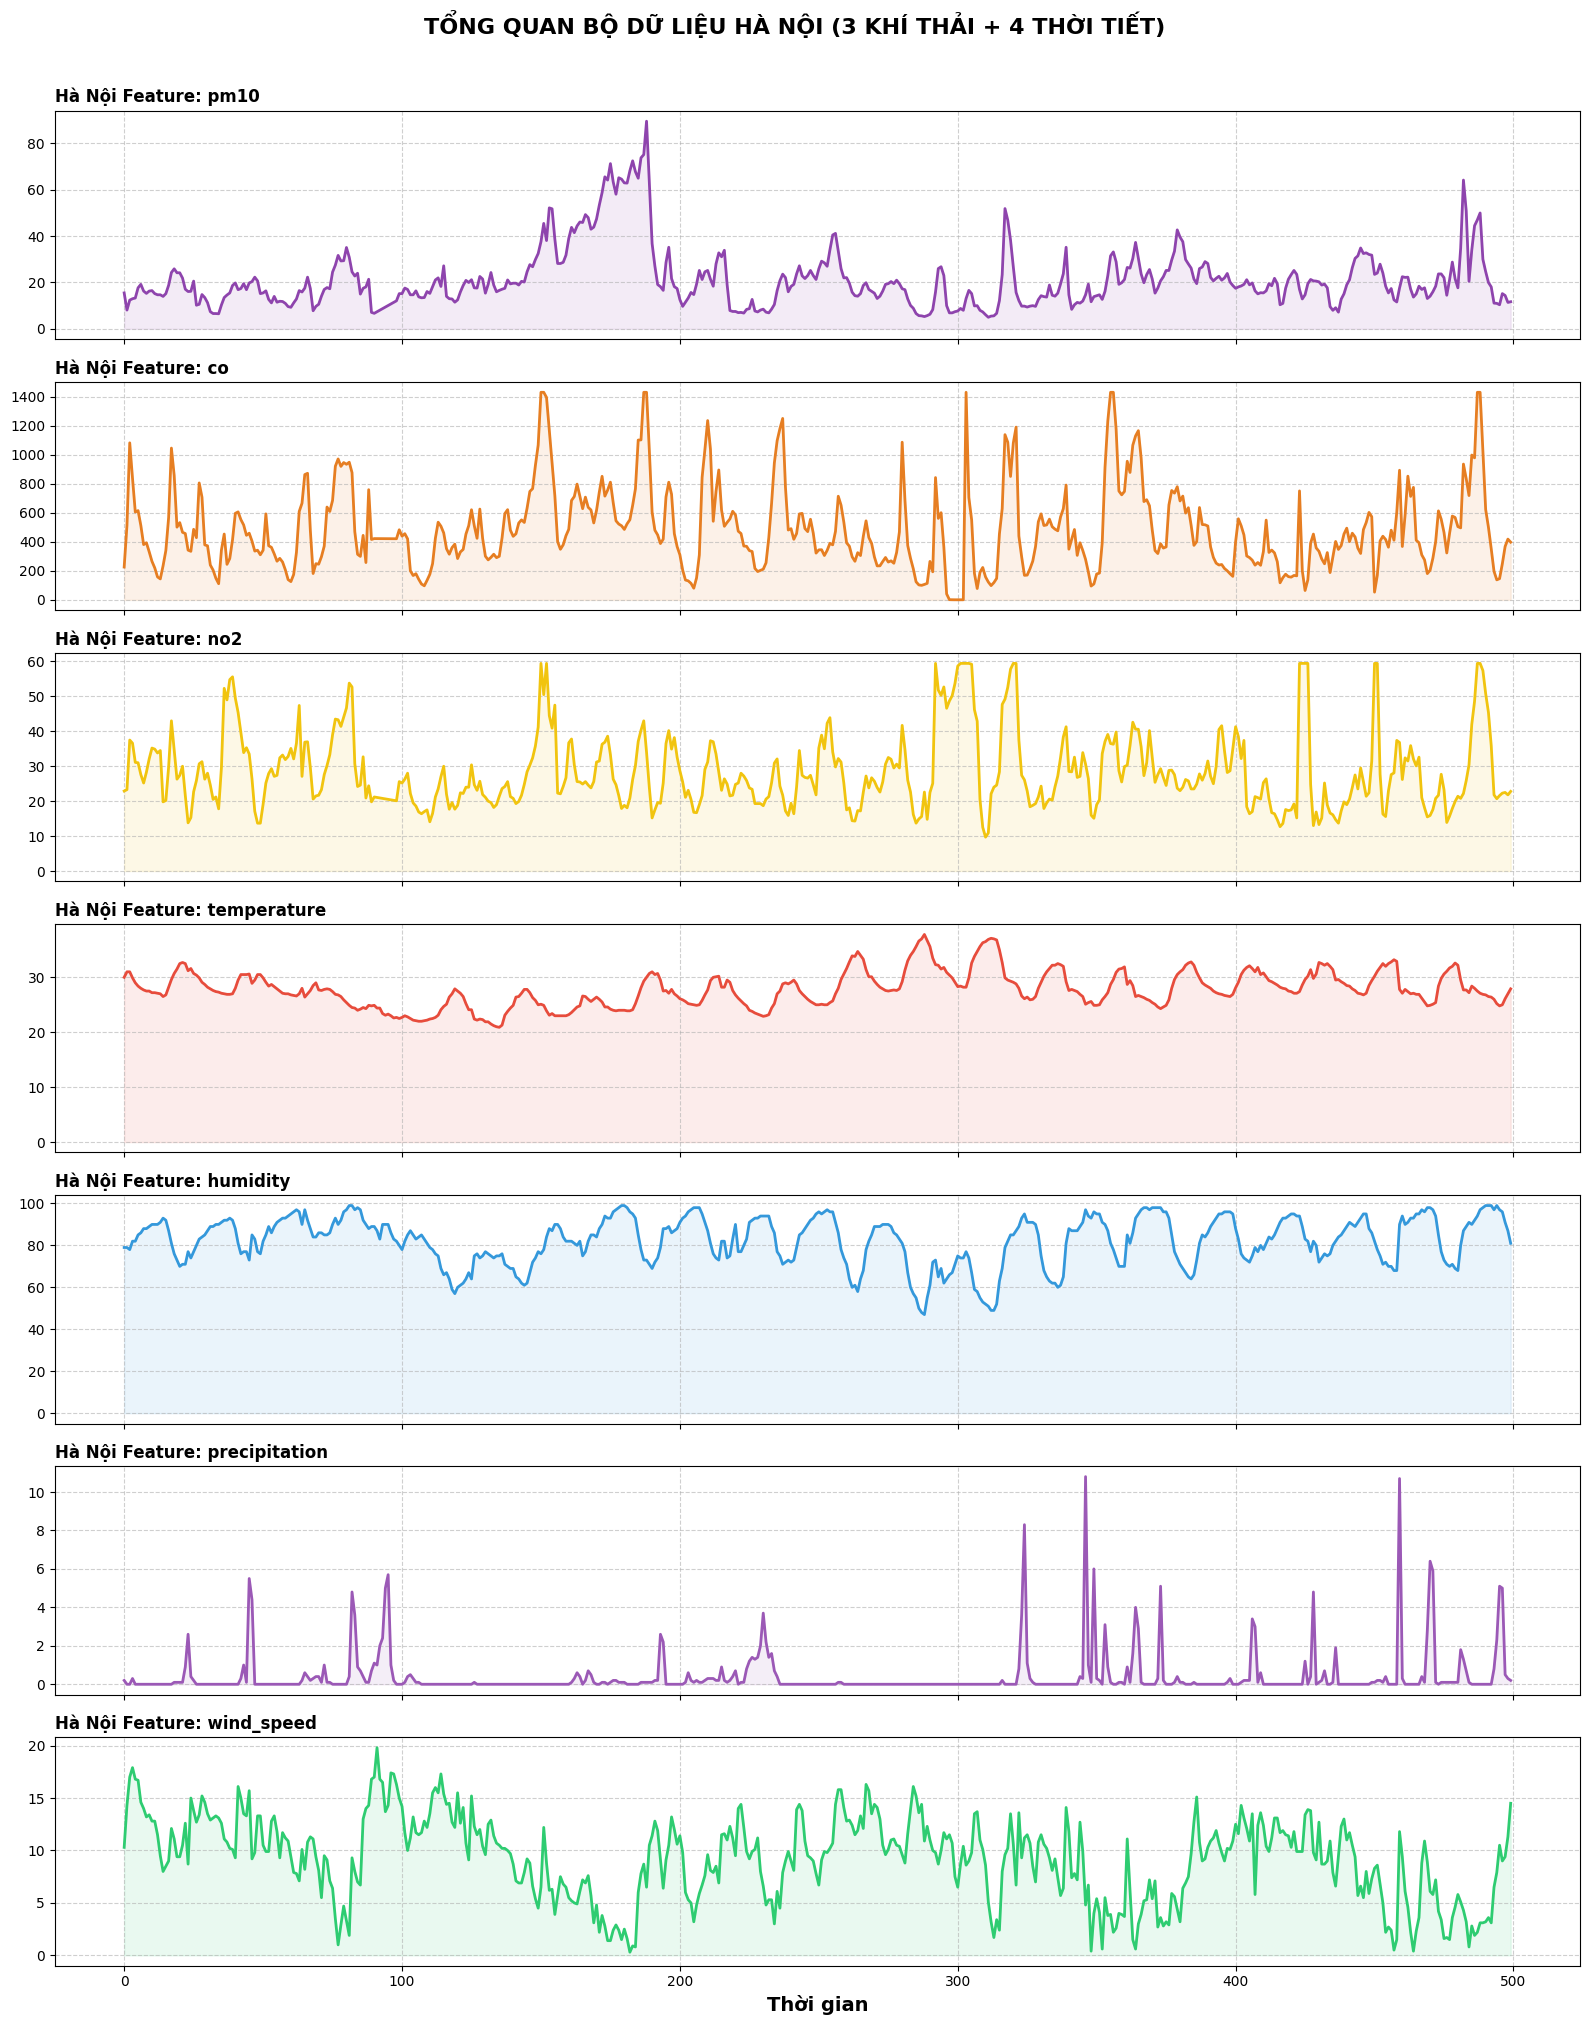

In [ ]:
# ==========================================
# CELL 3: TRỰC QUAN DỮ LIỆU TỰ THU THẬP (7 BIẾN)
# ==========================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tự động tạo thư mục Hanoi nếu chưa có
!mkdir -p /content/SOFTS/dataset/Hanoi/

file_path = '/content/SOFTS/dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv'

# 2. Kiểm tra xem file đã được upload chưa
if not os.path.exists(file_path):
    print("✅ Đã khởi tạo sẵn thư mục: /content/SOFTS/dataset/Hanoi/")
    print("⚠️ THIẾU DỮ LIỆU: Hệ thống chưa tìm thấy file CSV.")
    print("👉 HƯỚNG DẪN: Bạn hãy mở mục Files (cột bên trái Colab), tìm đến thư mục 'dataset' -> 'Hanoi', sau đó upload file 'Hanoi_AirQuality_Weather_7Vars.csv' vào đây. Upload xong hãy bấm CHẠY LẠI Cell này nhé!")
else:
    print("✅ Đã tìm thấy dữ liệu Hà Nội. Đang tiến hành vẽ biểu đồ...")
    df_hanoi = pd.read_csv(file_path)

    if 'date' in df_hanoi.columns:
        df_hanoi['date'] = pd.to_datetime(df_hanoi['date'])
        df_hanoi.set_index('date', inplace=True)

    # Lấy 500 giờ cuối để vẽ
    df_plot_hanoi = df_hanoi.iloc[-500:]
    cols = ['pm10', 'co', 'no2', 'temperature', 'humidity', 'precipitation', 'wind_speed']
    colors = ['#8e44ad', '#e67e22', '#f1c40f', '#e74c3c', '#3498db', '#9b59b6', '#2ecc71']

    fig, axes = plt.subplots(7, 1, figsize=(16, 20), sharex=True)
    for i, col in enumerate(cols):
        x_axis = df_plot_hanoi.index if 'date' in df_hanoi.columns else range(len(df_plot_hanoi))
        axes[i].plot(x_axis, df_plot_hanoi[col], color=colors[i], linewidth=2)
        axes[i].fill_between(x_axis, df_plot_hanoi[col], color=colors[i], alpha=0.1)
        axes[i].set_title(f"Hà Nội Feature: {col}", fontsize=12, fontweight='bold', loc='left')
        axes[i].grid(True, linestyle='--', alpha=0.6)

    plt.xlabel('Thời gian', fontsize=14, fontweight='bold')
    plt.suptitle('TỔNG QUAN BỘ DỮ LIỆU HÀ NỘI (3 KHÍ THẢI + 4 THỜI TIẾT)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
%%bash
# ==========================================
# CELL 4: HUẤN LUYỆN SOFTS VỚI ETTm1
# ==========================================
cd /content/SOFTS
python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/ETT-small/ \
  --data_path ETTm1.csv \
  --model_id ETTm1_quick_test \
  --model SOFTS \
  --data ETTm1 \
  --features M \
  --seq_len 96 \
  --label_len 48 \
  --pred_len 96 \
  --e_layers 1 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --d_model 64 \
  --d_core 32 \
  --d_ff 64 \
  --batch_size 16 \
  --learning_rate 0.0003 \
  --train_epochs 2 \
  --patience 1 \
  --des 'ETTm1_test' \
  --save_model

Args in experiment:
Namespace(task_name='long_term_forecast', is_training=1, model_id='ETTm1_quick_test', model='SOFTS', data='ETTm1', root_path='./dataset/ETT-small/', data_path='ETTm1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, seasonal_patterns='Monthly', enc_in=7, dec_in=7, c_out=7, d_model=64, d_core=32, e_layers=1, d_layers=1, d_ff=64, moving_avg=25, factor=1, distil=True, dropout=0.0, embed='timeF', activation='gelu', output_attention=False, attention_type='full', use_norm=True, num_workers=4, itr=1, train_epochs=2, batch_size=16, patience=1, learning_rate=0.0003, des='ETTm1_test', loss='MSE', lradj='type1', use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', save_model=True)
Use GPU: cuda:0
>>>>>>>start training : long_term_forecast_ETTm1_quick_test_SOFTS_ETTm1_ftM_sl96_ll48_pl96_dm64_el1_dl1_df64_fc1_ebtimeF_dtTrue_ETTm1_test>>>>>>>>>>>>>>>>>>>>>>>>>>
train 34369
val 11425
test 11425
	i

In [ ]:
%%writefile /content/SOFTS/visualize_ett.py
import os, sys, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import urllib.request
from matplotlib import font_manager as fm

sys.path.append('/content/SOFTS')
os.chdir('/content/SOFTS')
from models import SOFTS

# ==========================================
# BIỆN PHÁP MẠNH: TẢI VÀ ÉP FONT TRỰC TIẾP
# ==========================================
font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=14)
vi_font_legend = fm.FontProperties(fname=font_path, size=11)

# ==========================================
# CẤU HÌNH VÀ CHẠY MÔ HÌNH ETTm1
# ==========================================
class ConfigETT:
    def __init__(self):
        self.task_name = 'long_term_forecast'
        self.seq_len, self.label_len, self.pred_len = 96, 48, 96
        self.enc_in, self.dec_in, self.c_out = 7, 7, 7
        self.d_model, self.d_core, self.d_ff = 64, 32, 64
        self.e_layers, self.d_layers = 1, 1
        self.factor = 1
        self.distil, self.use_norm = True, True
        self.dropout, self.embed, self.activation = 0.0, 'timeF', 'gelu'
        self.output_attention, self.freq, self.features = False, 'h', 'M'

configs = ConfigETT()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = SOFTS.Model(configs).to(device)

ckpt_dir = '/content/SOFTS/checkpoints/'
# Tìm đúng thư mục checkpoint của ETTm1 đã train ở Cell 4
latest_ckpt = sorted([f for f in os.listdir(ckpt_dir) if 'ETTm1_quick_test' in f])[-1]
model.load_state_dict(torch.load(os.path.join(ckpt_dir, latest_ckpt, 'checkpoint.pth'), map_location=device))
model.eval()

# Nạp dữ liệu
df = pd.read_csv('./dataset/ETT-small/ETTm1.csv')
cols = ['HUFL','HULL','MUFL','MULL','LUFL','LULL','OT']
data_vals = df[cols].values

scaler = StandardScaler().fit(data_vals)
data_scaled = scaler.transform(data_vals)

start_idx = len(data_scaled) - configs.seq_len - configs.pred_len
input_seq = data_scaled[start_idx : start_idx + configs.seq_len]
true_seq = data_scaled[start_idx + configs.seq_len : start_idx + configs.seq_len + configs.pred_len]

batch_x = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0).to(device)
dec_inp = torch.zeros([1, configs.pred_len, configs.enc_in]).float().to(device)
dec_inp = torch.cat([batch_x[:, -configs.label_len:, :], dec_inp], dim=1).float().to(device)
batch_x_mark = torch.zeros((1, configs.seq_len, 4)).to(device)
batch_y_mark = torch.zeros((1, configs.label_len + configs.pred_len, 4)).to(device)

with torch.no_grad():
    pred_scaled = model(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -configs.pred_len:, :]

input_inv = scaler.inverse_transform(input_seq)
true_inv = scaler.inverse_transform(true_seq)
pred_inv = scaler.inverse_transform(pred_scaled)

# ==========================================
# VẼ BIỂU ĐỒ (DÙNG FONT ÉP CỨNG)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# SỬA LỖI ĐỘ DÀI: 96h quá khứ, 97h tương lai (để nối điểm mượt mà)
time_past, time_future = range(1, 97), range(96, 96 + 97)
plot_indices = [0, 1, 6] # Lấy 3 biến: HUFL, HULL, OT
titles = ['Nhiệt lượng HUFL', 'Nhiệt lượng HULL', 'Nhiệt độ dầu máy (OT - Biến mục tiêu)']
colors = ['#8e44ad', '#e67e22', '#2ecc71']

for i, col_idx in enumerate(plot_indices):
    axes[i].plot(time_past, input_inv[:, col_idx], color='gray', label='Quá khứ 96h', linewidth=2)
    axes[i].plot(time_future, np.insert(true_inv[:, col_idx], 0, input_inv[-1, col_idx]), color='black', label='Thực tế 96h', linewidth=3)
    axes[i].plot(time_future, np.insert(pred_inv[:, col_idx], 0, input_inv[-1, col_idx]), color=colors[i], label='Mô hình SOFTS Dự báo', linewidth=3, linestyle='--')
    axes[i].axvline(x=96, color='blue', linestyle='-.', linewidth=2)

    # Ép Font Tiếng Việt
    axes[i].set_title(f"Kiểm chứng Mô hình trên ETTm1: {titles[i]}", fontproperties=vi_font_title)
    axes[i].set_ylabel("Giá trị", fontproperties=vi_font)
    if i == 0: axes[i].legend(loc='upper left', prop=vi_font_legend)

plt.xlabel("Trục thời gian (Giờ)", fontproperties=vi_font)
plt.tight_layout()
plt.savefig('/content/SOFTS/ETT_Prediction_Fixed.png', dpi=300)
print("✅ Đã xuất ảnh ETT thành công!")

Writing /content/SOFTS/visualize_ett.py


✅ Đã xuất ảnh ETT thành công!


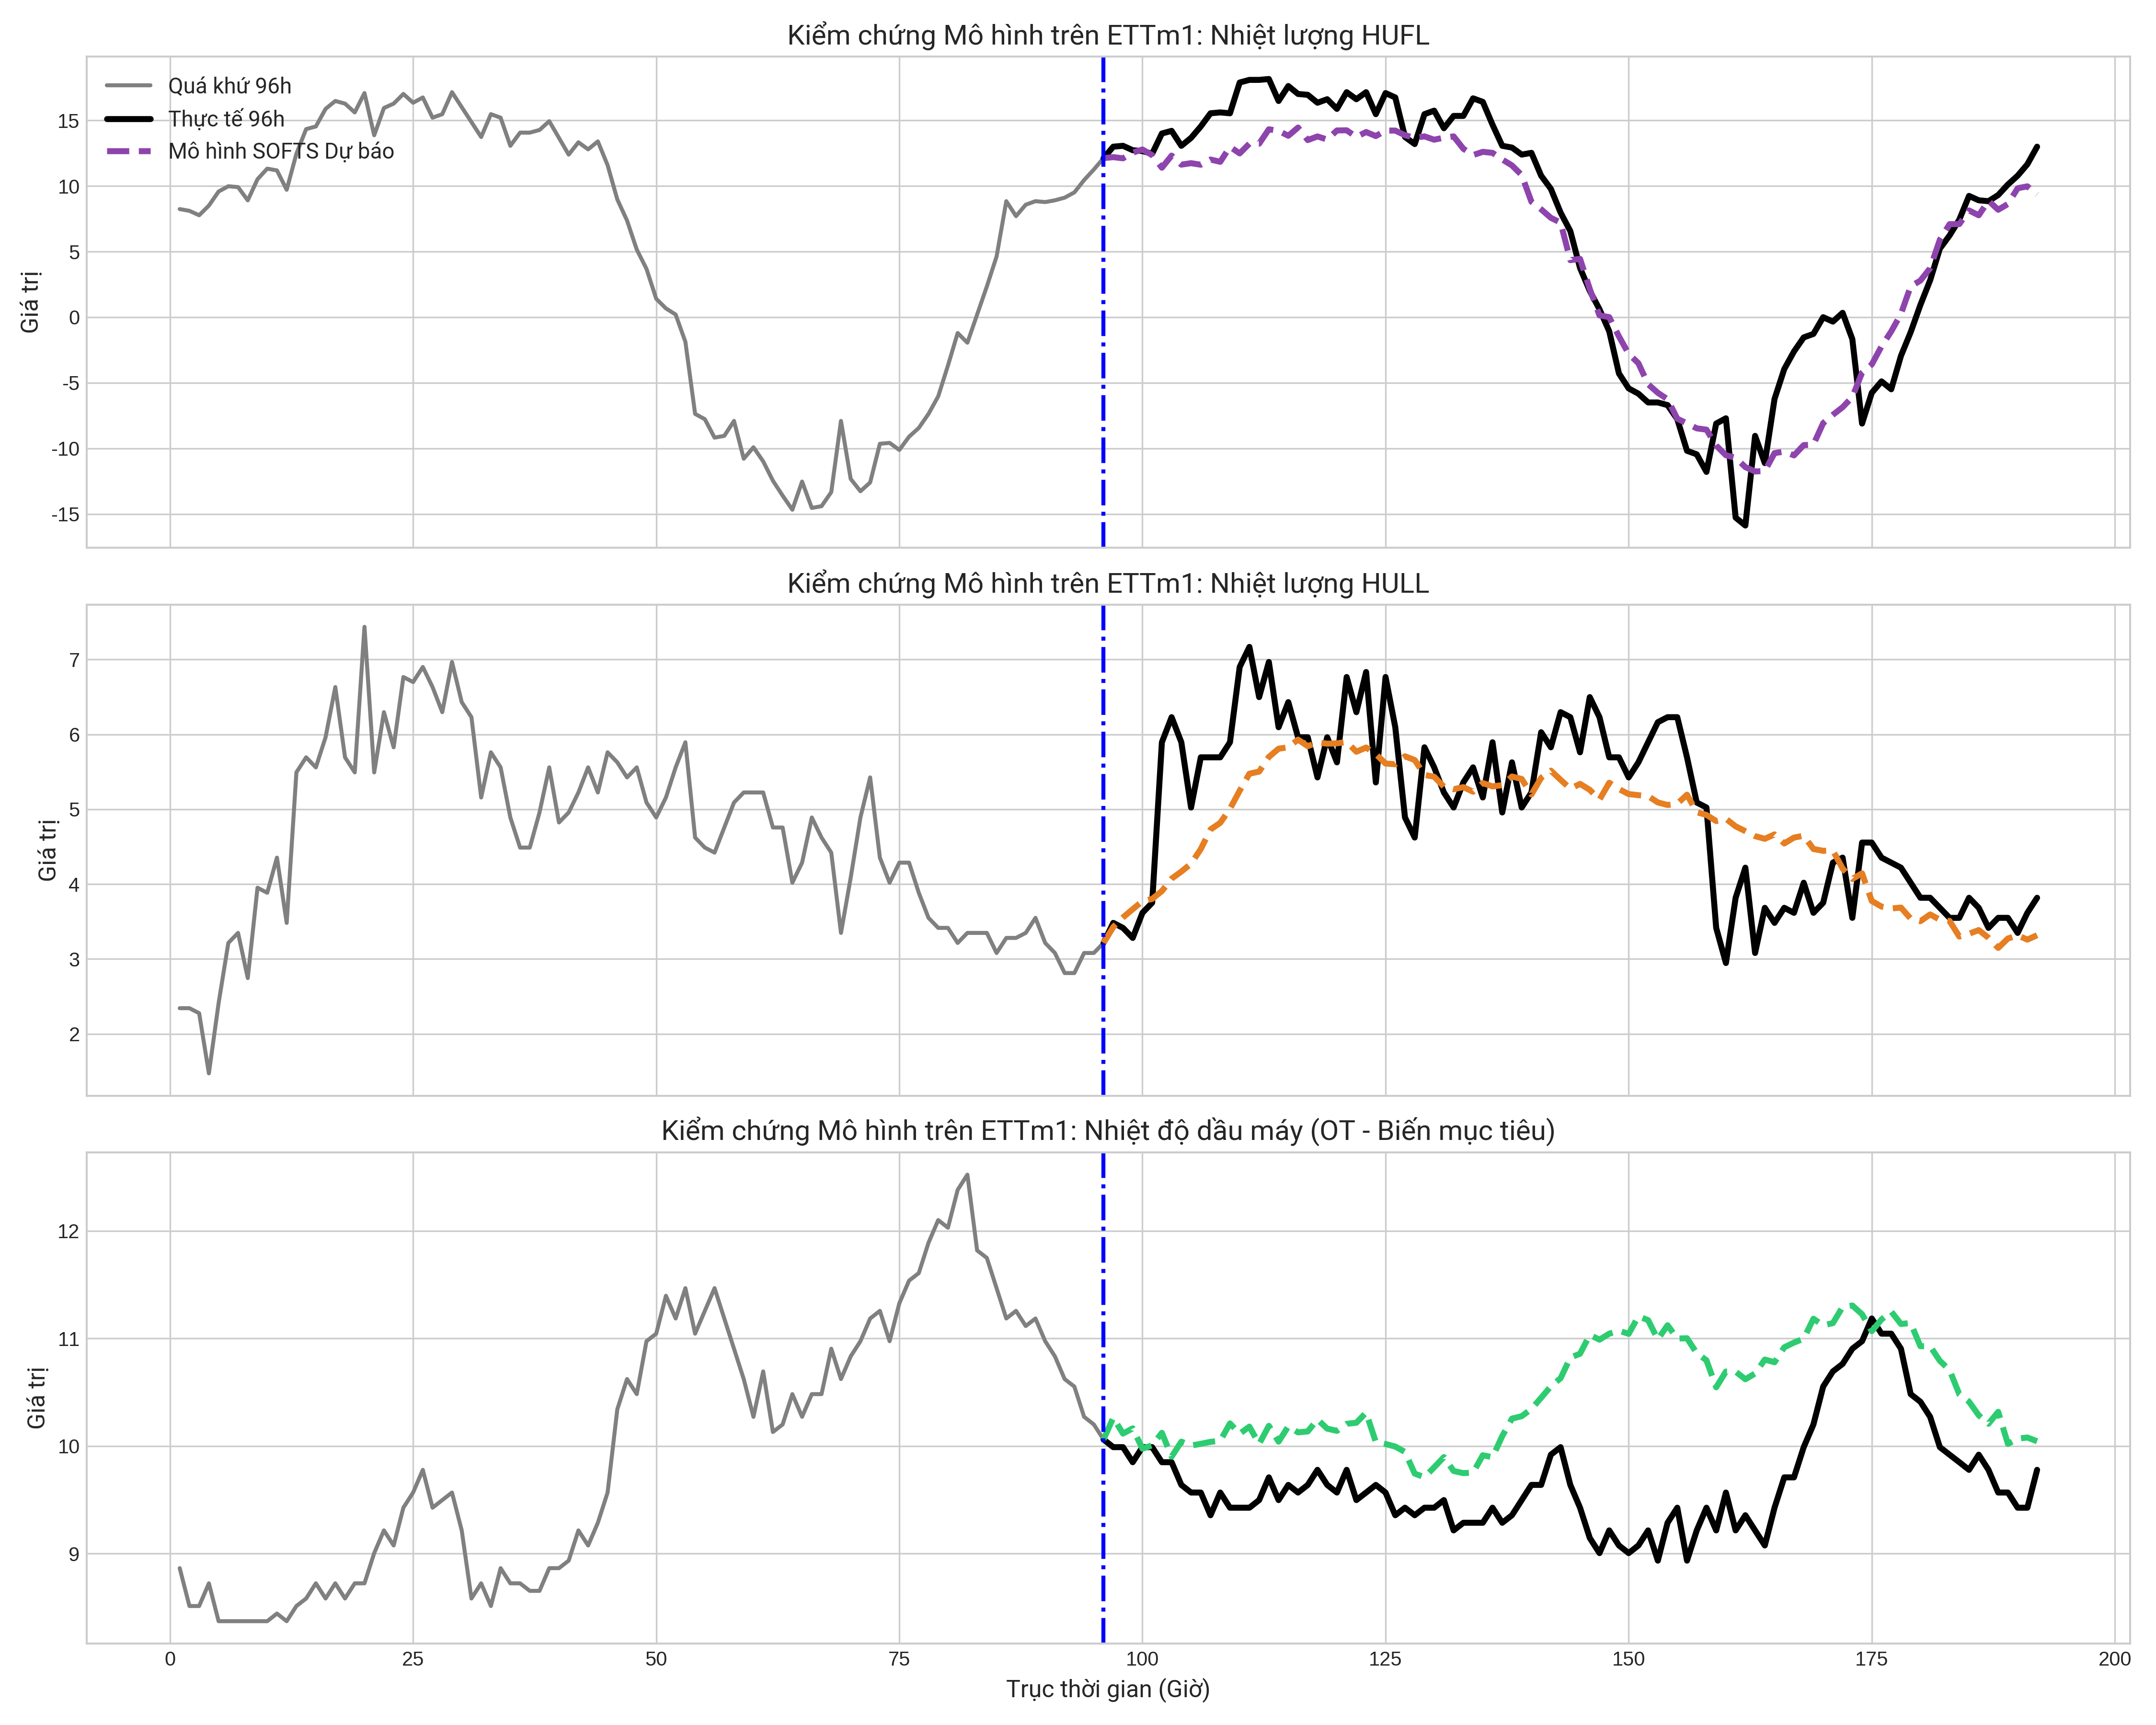

In [ ]:
!python /content/SOFTS/visualize_ett.py
from IPython.display import Image, display
display(Image('/content/SOFTS/ETT_Prediction_Fixed.png'))

In [ ]:
%%bash
# ==========================================
# CELL 7: HUẤN LUYỆN SOFTS 7 BIẾN HÀ NỘI
# ==========================================
cd /content/SOFTS
python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path ./dataset/Hanoi/ \
  --data_path Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv \
  --model_id Hanoi_7Vars_192_24_Tuned \
  --model SOFTS \
  --data custom \
  --features M \
  --target pm10 \
  --seq_len 192 \
  --label_len 96 \
  --pred_len 24 \
  --e_layers 2 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --d_model 128 \
  --d_core 64 \
  --d_ff 128 \
  --batch_size 32 \
  --learning_rate 0.0001 \
  --train_epochs 10 \
  --patience 3 \
  --des 'Hanoi_7Vars' \
  --save_model

Args in experiment:
Namespace(task_name='long_term_forecast', is_training=1, model_id='Hanoi_7Vars_192_24_Tuned', model='SOFTS', data='custom', root_path='./dataset/Hanoi/', data_path='Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv', features='M', target='pm10', freq='h', checkpoints='./checkpoints/', seq_len=192, label_len=96, pred_len=24, seasonal_patterns='Monthly', enc_in=7, dec_in=7, c_out=7, d_model=128, d_core=64, e_layers=2, d_layers=1, d_ff=128, moving_avg=25, factor=1, distil=True, dropout=0.0, embed='timeF', activation='gelu', output_attention=False, attention_type='full', use_norm=True, num_workers=4, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='Hanoi_7Vars', loss='MSE', lradj='type1', use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', save_model=True)
Use GPU: cuda:0
>>>>>>>start training : long_term_forecast_Hanoi_7Vars_192_24_Tuned_SOFTS_custom_ftM_sl192_ll96_pl24_dm128_el2_dl1_df128_fc1_ebtimeF_dtTrue_Hanoi_7Va

In [ ]:
%%writefile /content/SOFTS/visualize_hanoi.py
import os, sys, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import urllib.request
from matplotlib import font_manager as fm

sys.path.append('/content/SOFTS')
os.chdir('/content/SOFTS')
from models import SOFTS

# ==========================================
# BIỆN PHÁP MẠNH: TẢI VÀ ÉP FONT TRỰC TIẾP
# ==========================================
font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

# Tạo đối tượng Font đặc biệt (bỏ qua mọi hệ thống cache của Linux)
vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=14)
vi_font_legend = fm.FontProperties(fname=font_path, size=11)

# ==========================================
# CẤU HÌNH VÀ CHẠY MÔ HÌNH
# ==========================================
class ConfigHanoi:
    def __init__(self):
        self.task_name = 'long_term_forecast'
        self.seq_len, self.label_len, self.pred_len = 192, 96, 24
        self.enc_in, self.dec_in, self.c_out = 7, 7, 7
        self.d_model, self.d_core, self.d_ff = 128, 64, 128
        self.e_layers, self.d_layers = 2, 1
        self.factor = 1
        self.distil, self.use_norm = True, True
        self.dropout, self.embed, self.activation = 0.0, 'timeF', 'gelu'
        self.output_attention, self.freq, self.features = False, 'h', 'M'

configs = ConfigHanoi()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = SOFTS.Model(configs).to(device)

ckpt_dir = '/content/SOFTS/checkpoints/'
latest_ckpt = sorted([f for f in os.listdir(ckpt_dir) if 'Hanoi_7Vars' in f])[-1]
model.load_state_dict(torch.load(os.path.join(ckpt_dir, latest_ckpt, 'checkpoint.pth'), map_location=device))
model.eval()

df = pd.read_csv('./dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv')
cols_7 = ['pm10', 'co', 'no2', 'temperature', 'humidity', 'precipitation', 'wind_speed']
data_vals = df[cols_7].values

scaler = StandardScaler().fit(data_vals)
data_scaled = scaler.transform(data_vals)

start_idx = len(data_scaled) - configs.seq_len - configs.pred_len
input_seq = data_scaled[start_idx : start_idx + configs.seq_len]
true_seq = data_scaled[start_idx + configs.seq_len : start_idx + configs.seq_len + configs.pred_len]

batch_x = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0).to(device)
dec_inp = torch.zeros([1, configs.pred_len, configs.enc_in]).float().to(device)
dec_inp = torch.cat([batch_x[:, -configs.label_len:, :], dec_inp], dim=1).float().to(device)
batch_x_mark, batch_y_mark = torch.zeros((1, configs.seq_len, 4)).to(device), torch.zeros((1, configs.label_len + configs.pred_len, 4)).to(device)

with torch.no_grad():
    pred_scaled = model(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -configs.pred_len:, :]

input_inv, true_inv, pred_inv = scaler.inverse_transform(input_seq), scaler.inverse_transform(true_seq), scaler.inverse_transform(pred_scaled)

# ==========================================
# VẼ BIỂU ĐỒ (DÙNG FONT ÉP CỨNG)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False # Fix lỗi dấu âm
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

time_past, time_future = range(1, 193), range(192, 192 + 25)
titles, colors = ['Bụi mịn PM10', 'Khí CO', 'Khí NO2'], ['#8e44ad', '#e67e22', '#f1c40f']

for i in range(3):
    axes[i].plot(time_past, input_inv[:, i], color='gray', label='Quá khứ 192h', linewidth=2)
    axes[i].plot(time_future, np.insert(true_inv[:, i], 0, input_inv[-1, i]), color='black', label='Thực tế 24h', linewidth=3)
    axes[i].plot(time_future, np.insert(pred_inv[:, i], 0, input_inv[-1, i]), color=colors[i], label='Cảnh báo SOFTS', linewidth=3, linestyle='--')
    axes[i].axvline(x=192, color='blue', linestyle='-.', linewidth=2)

    # CHÈN FONT TRỰC TIẾP VÀO TỪNG DÒNG CHỮ
    axes[i].set_title(f"Hệ thống Cảnh báo Sớm: {titles[i]} (Học từ 7 biến Thời tiết)", fontproperties=vi_font_title)
    axes[i].set_ylabel("Nồng độ", fontproperties=vi_font)

    if i == 0:
        axes[i].legend(loc='upper left', prop=vi_font_legend)

plt.xlabel("Trục thời gian (Giờ)", fontproperties=vi_font)
plt.tight_layout()
plt.savefig('/content/SOFTS/Hanoi_Prediction.png', dpi=300)
print("✅ Đã xuất ảnh thành công!")

Writing /content/SOFTS/visualize_hanoi.py


✅ Đã xuất ảnh thành công!


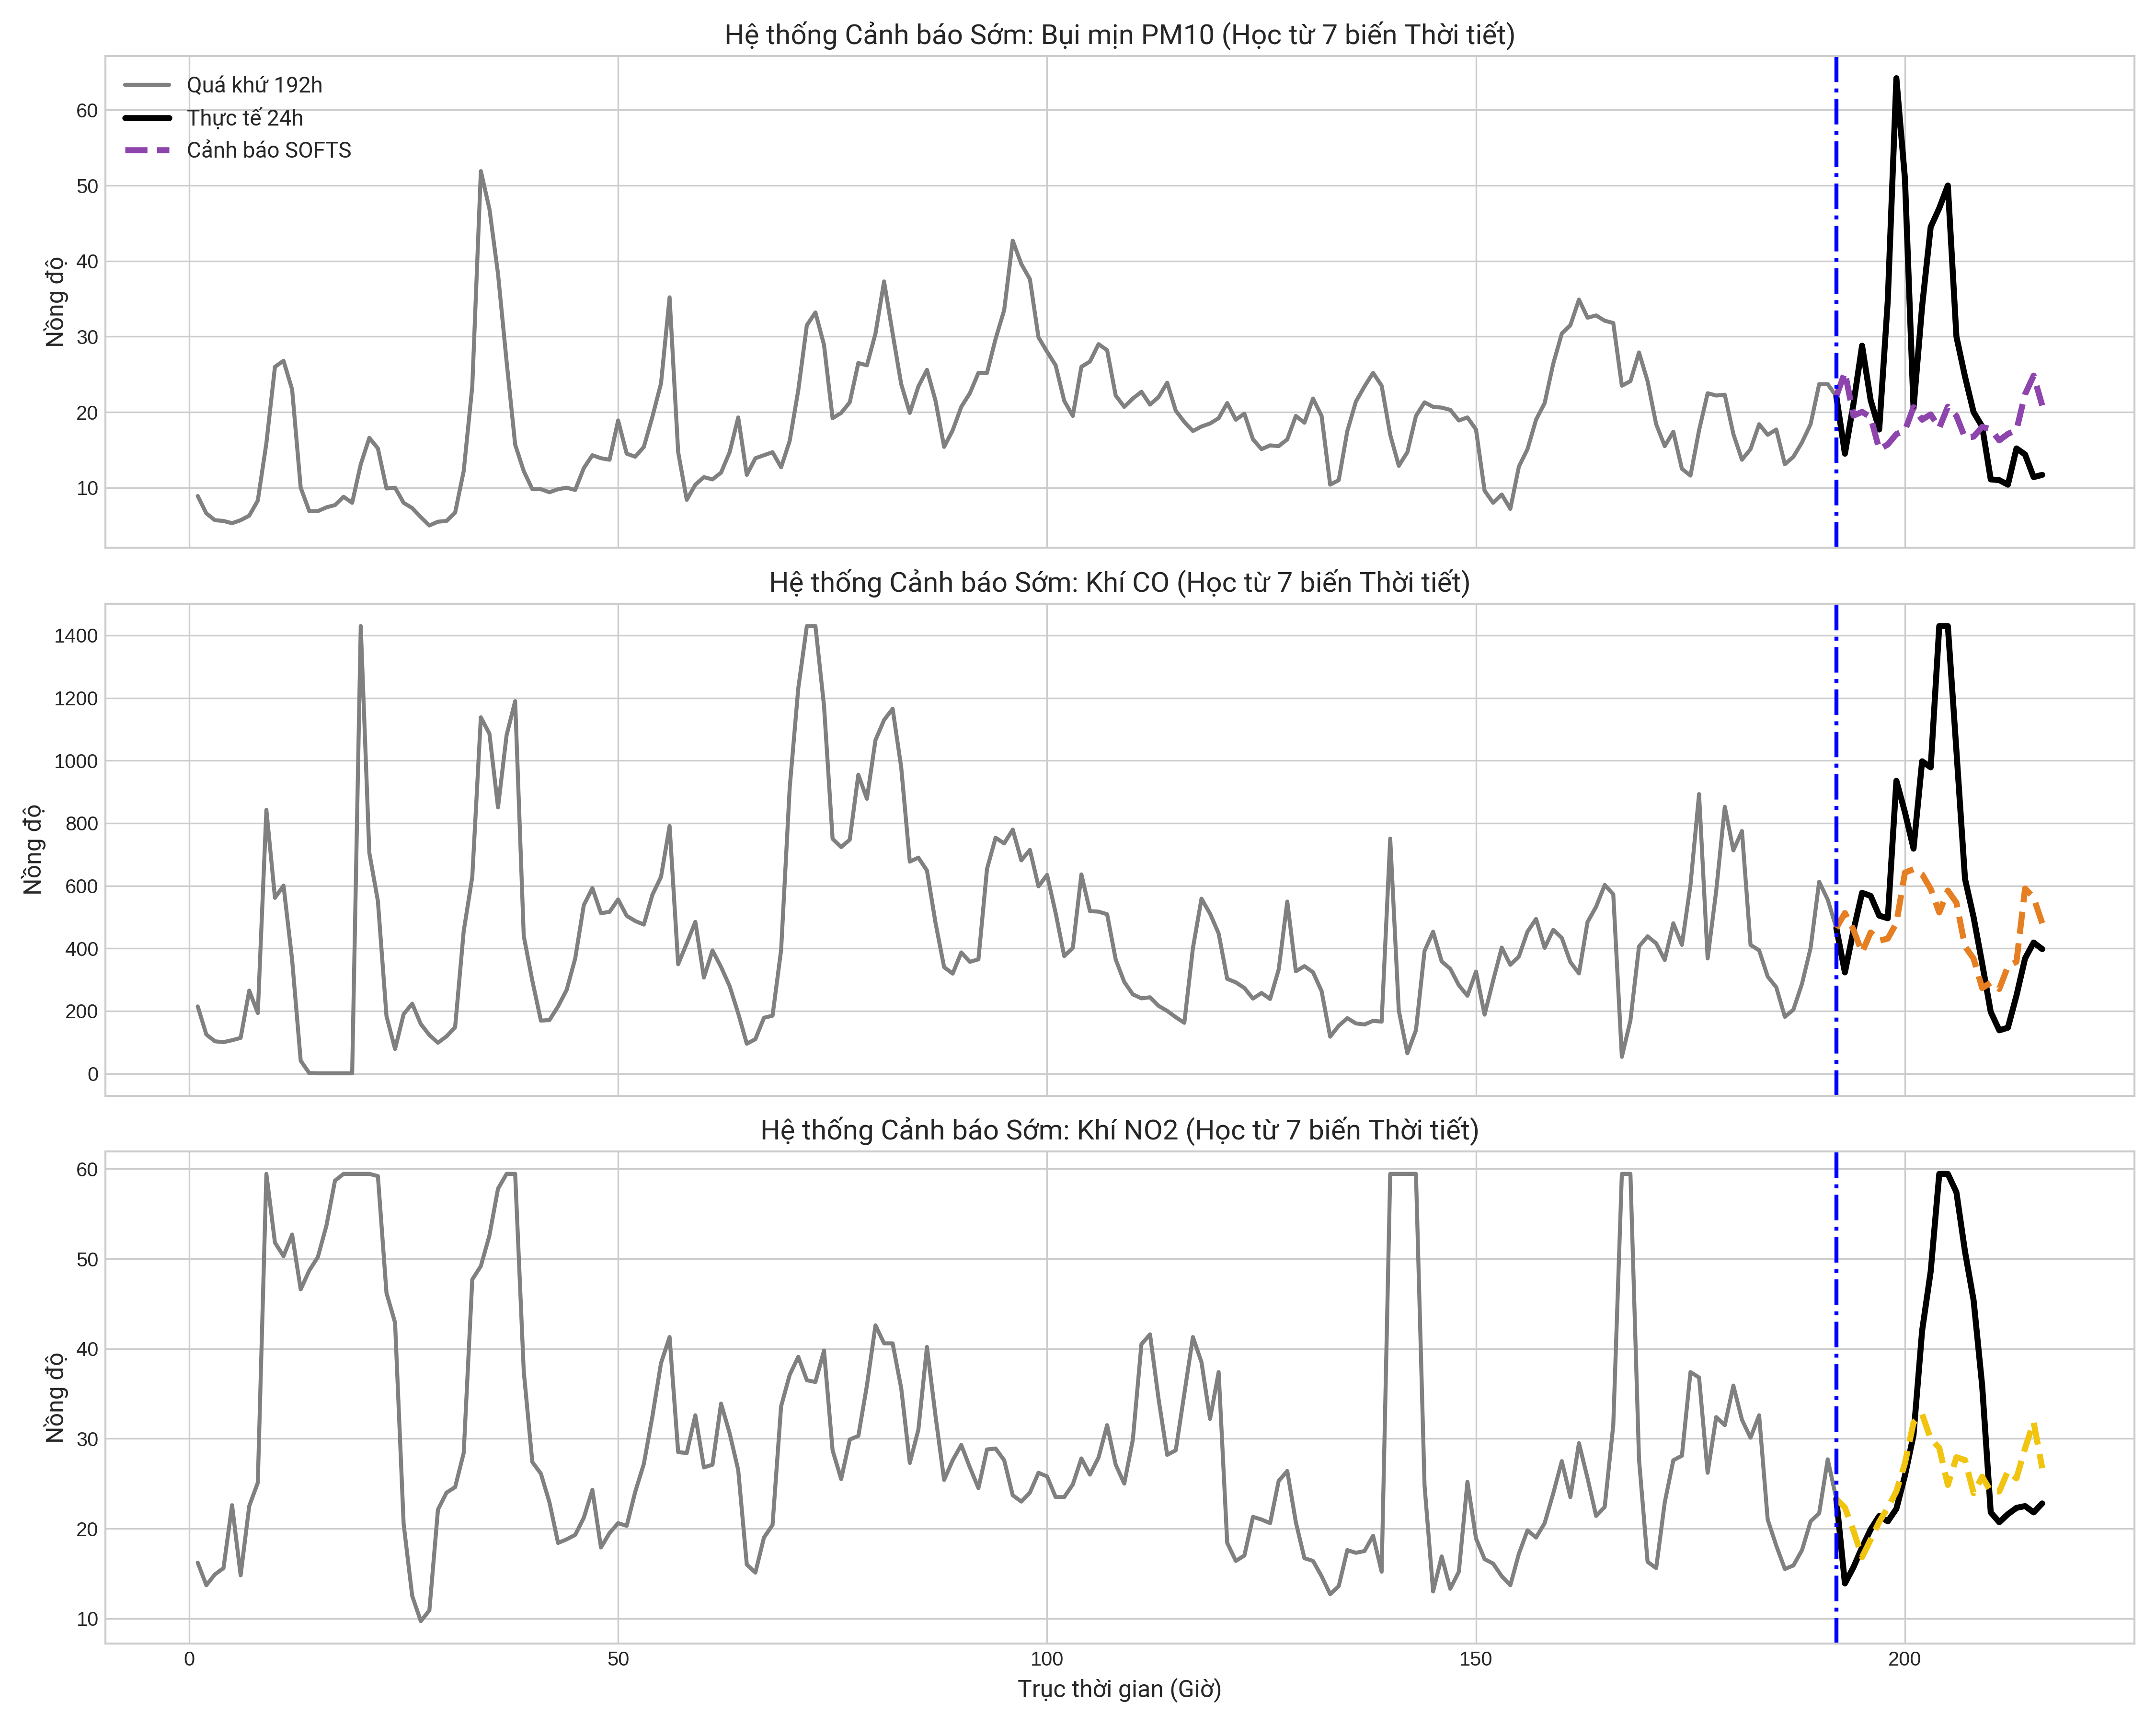

In [ ]:
!python /content/SOFTS/visualize_hanoi.py
from IPython.display import Image, display
display(Image('/content/SOFTS/Hanoi_Prediction.png'))

In [ ]:
%%writefile /content/SOFTS/ablation_visualization_pro_co.py
import os, sys, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import urllib.request
from matplotlib import font_manager as fm

sys.path.append('/content/SOFTS')
os.chdir('/content/SOFTS')
from models import SOFTS

# Tải Font
font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path): urllib.request.urlretrieve(font_url, font_path)
vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
vi_font_legend = fm.FontProperties(fname=font_path, size=11)
vi_font_small = fm.FontProperties(fname=font_path, size=14)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

class ConfigFull:
    def __init__(self):
        self.task_name, self.seq_len, self.label_len, self.pred_len = 'long_term_forecast', 192, 96, 24
        self.enc_in, self.dec_in, self.c_out = 7, 7, 7
        self.d_model, self.d_core, self.d_ff, self.e_layers, self.d_layers = 128, 64, 128, 2, 1
        self.factor, self.distil, self.embed, self.activation, self.use_norm = 1, True, 'timeF', 'gelu', True
        self.output_attention, self.freq, self.features = False, 'h', 'M'
        self.dropout = 0.0

configs = ConfigFull()
model_full = SOFTS.Model(configs).to(device)

import copy
model_ablated = copy.deepcopy(model_full)
for name, module in model_ablated.named_modules():
    if 'core_projection' in name or 'mlp' in name.lower() or 'ffn' in name.lower():
        setattr(model_ablated, name.split('.')[-1], torch.nn.Identity())

ckpt_dir = '/content/SOFTS/checkpoints/'
try:
    ckpt_full = sorted([f for f in os.listdir(ckpt_dir) if 'Hanoi_7Vars' in f and 'NoNorm' not in f and 'NoTime' not in f])[-1]
    model_full.load_state_dict(torch.load(os.path.join(ckpt_dir, ckpt_full, 'checkpoint.pth'), map_location=device))
    model_full.eval(); model_ablated.eval()
except Exception as e:
    print(f"Lỗi load model: {e}")

df = pd.read_csv('./dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv')
data_vals = df[['pm10', 'co', 'no2', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values

scaler = StandardScaler().fit(data_vals)
data_scaled = scaler.transform(data_vals)

start_idx = len(data_scaled) - 192 - 24
input_seq = data_scaled[start_idx : start_idx + 192]
true_seq = data_scaled[start_idx + 192 : start_idx + 192 + 24]

batch_x = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0).to(device)
dec_inp = torch.zeros([1, 24, 7]).float().to(device)
dec_inp = torch.cat([batch_x[:, -96:, :], dec_inp], dim=1).float().to(device)
batch_x_mark, batch_y_mark = torch.zeros((1, 192, 4)).to(device), torch.zeros((1, 96 + 24, 4)).to(device)

with torch.no_grad():
    pred_full = model_full(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -24:, :]
    pred_ablated = model_ablated(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -24:, :]

input_inv = scaler.inverse_transform(input_seq)
true_inv = scaler.inverse_transform(true_seq)
pred_full_inv = scaler.inverse_transform(pred_full)
pred_ablated_inv = scaler.inverse_transform(pred_ablated)

# ==========================================
# TRỌNG TÂM: ĐỔI SANG BIẾN CO (Index 1)
# ==========================================
target_idx = 1 # 0=PM10, 1=CO, 2=NO2
target_name = 'Khí Carbon Monoxide (CO)'
color_full = '#e67e22' # Màu cam cho CO

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False

past_lookback = 48
past_inv_plot = input_inv[-past_lookback:, target_idx]
time_past = range(1, past_lookback + 1)
time_future = range(past_lookback, past_lookback + 25)

true_plot = np.insert(true_inv[:, target_idx], 0, past_inv_plot[-1])
pred_full_plot = np.insert(pred_full_inv[:, target_idx], 0, past_inv_plot[-1])
pred_ablated_plot = np.insert(pred_ablated_inv[:, target_idx], 0, past_inv_plot[-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, sharey=True)
fig.suptitle(f'ABLATION STUDY: Tác động của Module MLP đối với Dự báo {target_name}', fontproperties=vi_font_title, y=0.95)

# --- AX1: MÔ HÌNH HOÀN CHỈNH ---
ax1.plot(time_past, past_inv_plot, color='gray', label='Quá khứ 48h', linewidth=2)
ax1.plot(time_future, true_plot, color='black', label='Thực tế 24h', linewidth=3)
ax1.plot(time_future, pred_full_plot, color=color_full, label='SOFTS (Hoàn chỉnh)', linewidth=3)
ax1.fill_between(time_future, true_plot, pred_full_plot, color=color_full, alpha=0.3, label='Vùng sai số (Bám sát xu hướng chu kỳ)')
ax1.axvline(x=past_lookback, color='gray', linestyle='--', linewidth=2)
ax1.set_title("Trường hợp 1: Kiến trúc Mạng Nơ-ron Hoàn chỉnh (Có MLP)", fontproperties=vi_font_small)
ax1.set_ylabel("Nồng độ (CO)", fontproperties=vi_font)
ax1.legend(loc='upper left', prop=vi_font_legend)

# --- AX2: MÔ HÌNH BỊ CẮT MODULE ---
ax2.plot(time_past, past_inv_plot, color='gray', label='Quá khứ 48h', linewidth=2)
ax2.plot(time_future, true_plot, color='black', label='Thực tế 24h', linewidth=3)
ax2.plot(time_future, pred_ablated_plot, color='#e74c3c', label='SOFTS (Bị tháo MLP)', linewidth=3, linestyle='--')
ax2.fill_between(time_future, true_plot, pred_ablated_plot, color='#e74c3c', alpha=0.4, label='Vùng sai số vỡ nát (Mất khả năng học quy luật)')
ax2.axvline(x=past_lookback, color='gray', linestyle='--', linewidth=2)
ax2.set_title("Trường hợp 2: Mô hình bị phẫu thuật cắt bỏ Module trung tâm", fontproperties=vi_font_small)
ax2.set_xlabel("Trục thời gian (Giờ)", fontproperties=vi_font)
ax2.set_ylabel("Nồng độ (CO)", fontproperties=vi_font)
ax2.legend(loc='upper left', prop=vi_font_legend)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/content/SOFTS/Ablation_CO_Pro.png', dpi=300)
print("✅ Đã xuất ảnh Ablation CO thành công!")

Writing /content/SOFTS/ablation_visualization_pro_co.py


✅ Đã xuất ảnh Ablation CO thành công!


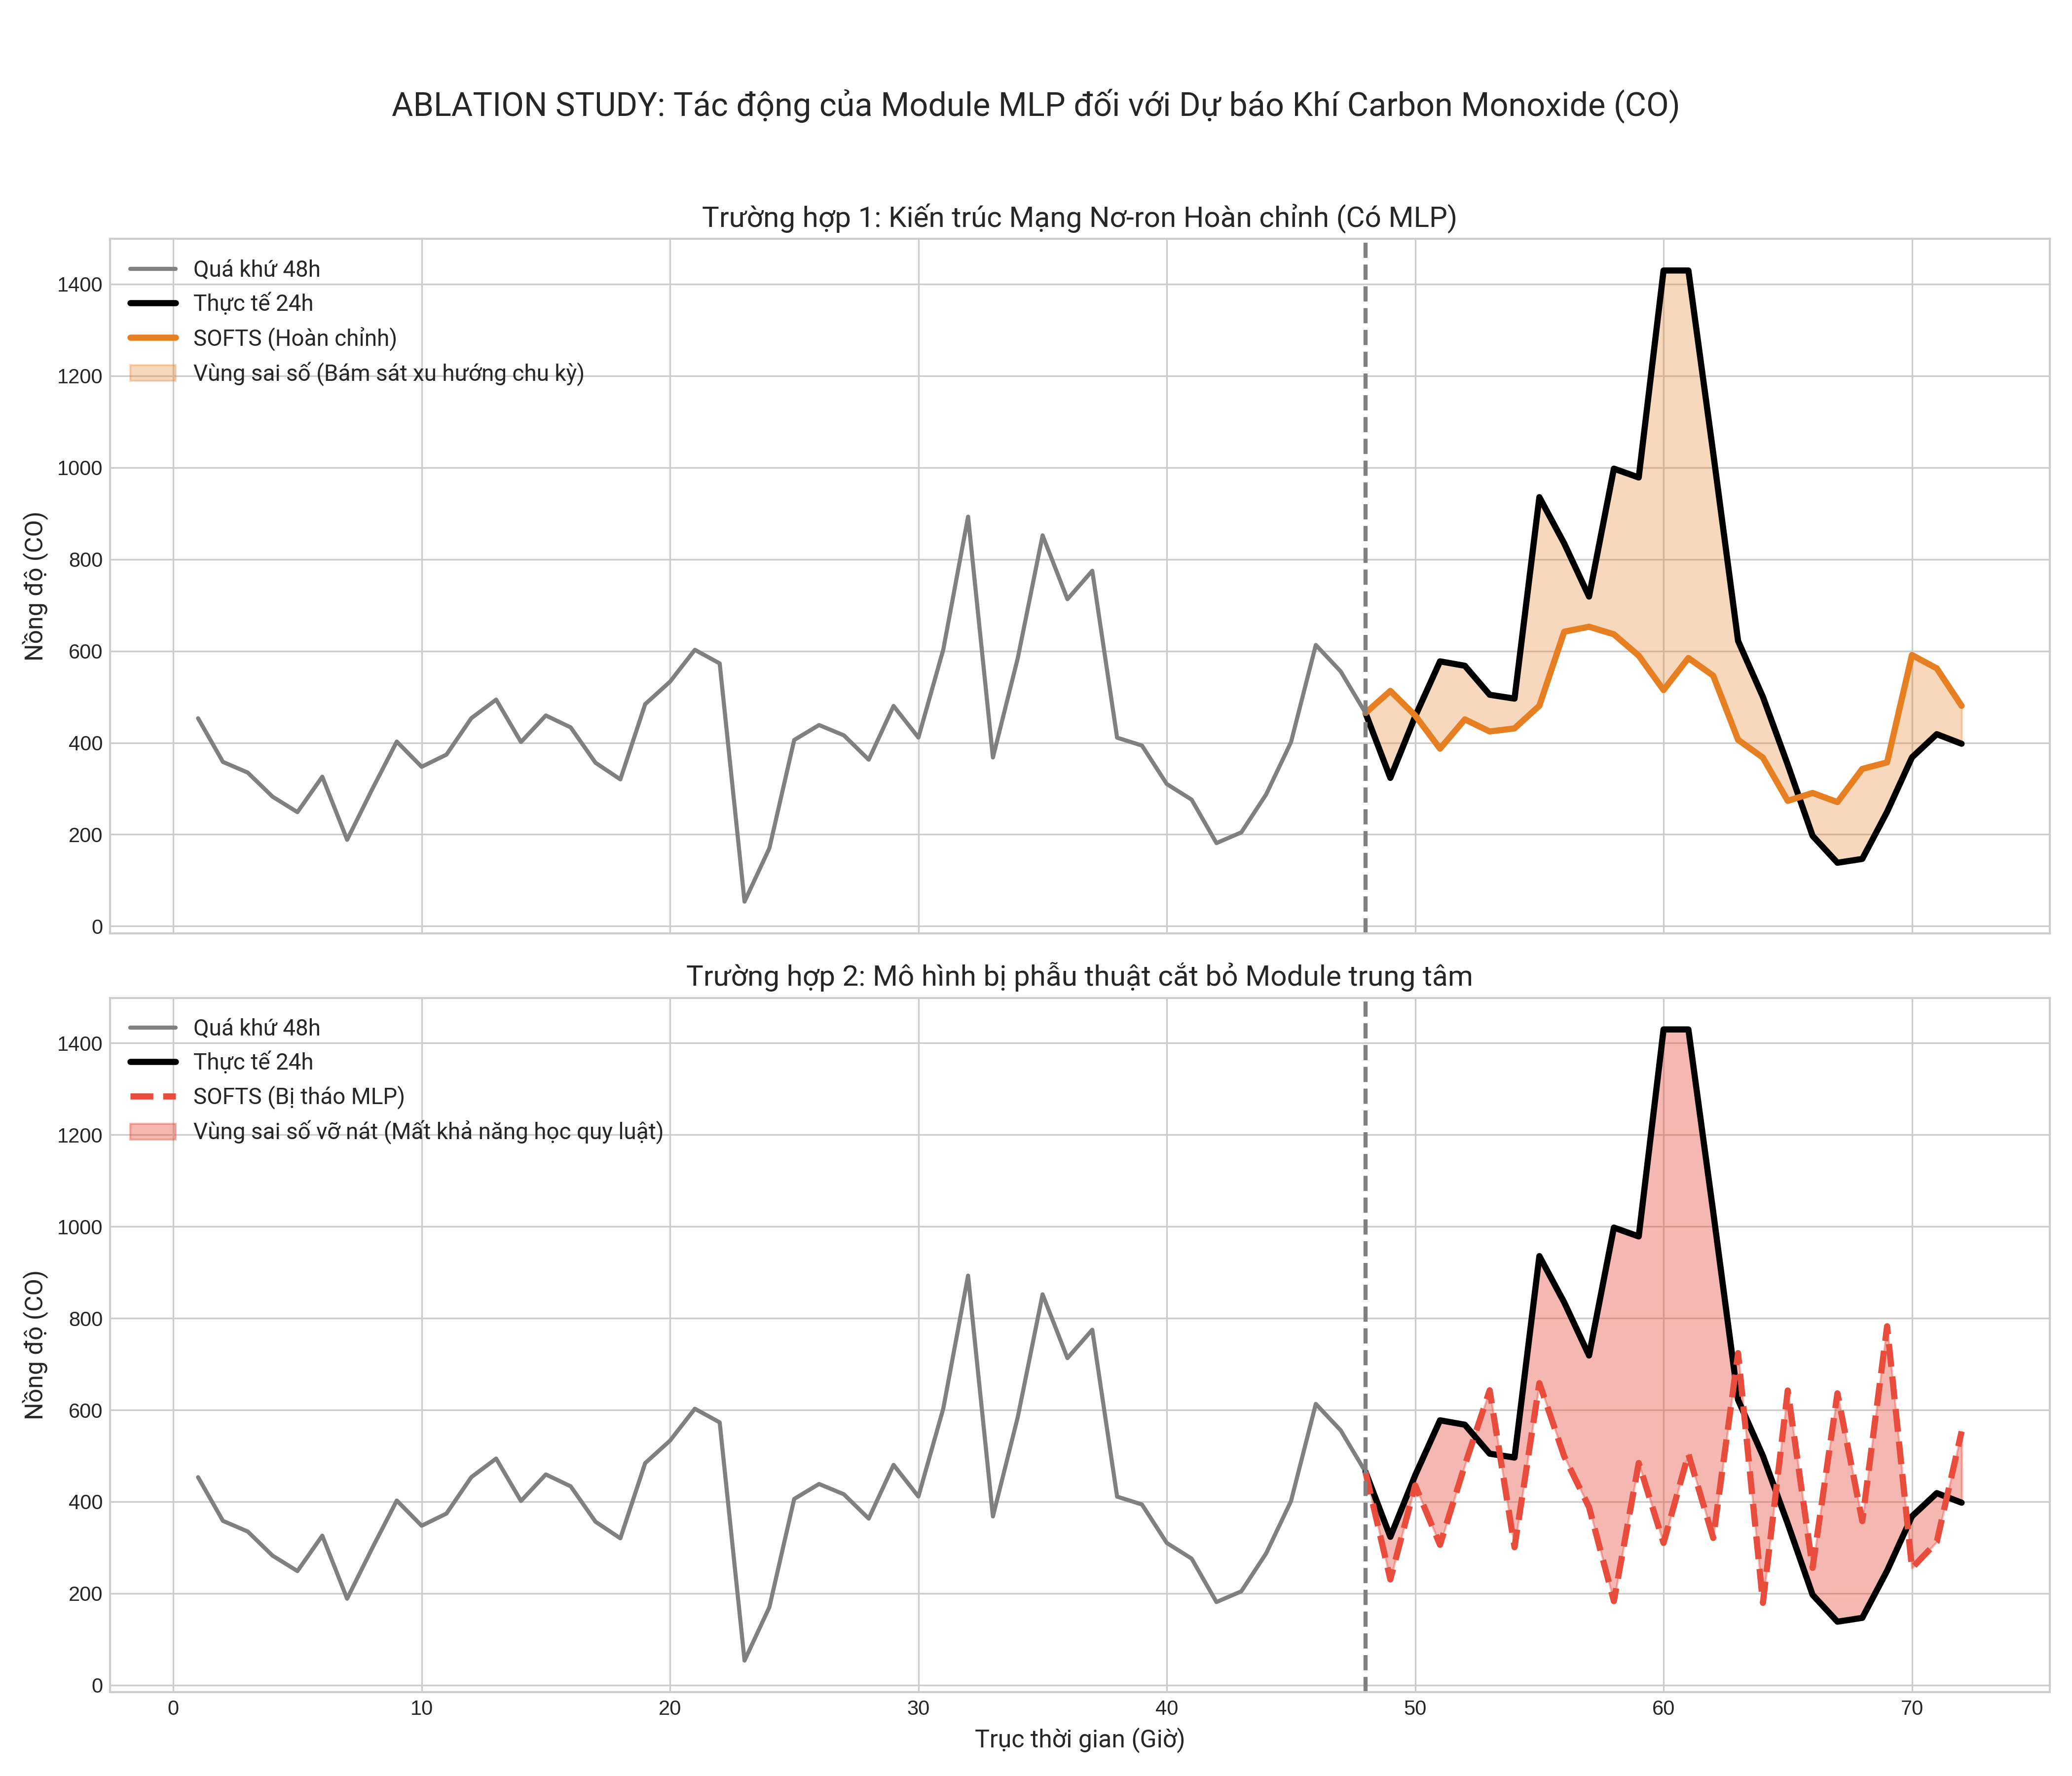

In [ ]:
!python /content/SOFTS/ablation_visualization_pro_co.py
from IPython.display import Image, display
display(Image('/content/SOFTS/Ablation_CO_Pro.png'))

In [ ]:
%%bash
cd /content/SOFTS
python -u run.py \
  --task_name long_term_forecast \
  --is_training 1 \
  --root_path /content/SOFTS/dataset/Hanoi/ \
  --data_path Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv \
  --model_id Hanoi_7Vars_NoTime \
  --model SOFTS \
  --data custom \
  --features M \
  --target pm10 \
  --seq_len 192 \
  --label_len 96 \
  --pred_len 24 \
  --e_layers 2 \
  --enc_in 7 \
  --dec_in 7 \
  --c_out 7 \
  --d_model 128 \
  --d_core 64 \
  --d_ff 128 \
  --batch_size 32 \
  --learning_rate 0.0001 \
  --train_epochs 10 \
  --patience 3 \
  --embed fixed \
  --des 'Ablation_Temporal' \
  --save_model

Process is terminated.


In [ ]:
%%writefile /content/SOFTS/ablation_visualization_pro_time.py
import os, sys, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import urllib.request
from matplotlib import font_manager as fm

sys.path.append('/content/SOFTS')
os.chdir('/content/SOFTS')
from models import SOFTS

# Tải Font
font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path): urllib.request.urlretrieve(font_url, font_path)
vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
vi_font_legend = fm.FontProperties(fname=font_path, size=11)
vi_font_small = fm.FontProperties(fname=font_path, size=14)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# 1. CẤU HÌNH MÔ HÌNH HOÀN CHỈNH (CÓ NHÚNG THỜI GIAN)
class ConfigFull:
    def __init__(self):
        self.task_name, self.seq_len, self.label_len, self.pred_len = 'long_term_forecast', 192, 96, 24
        self.enc_in, self.dec_in, self.c_out = 7, 7, 7
        self.d_model, self.d_core, self.d_ff, self.e_layers, self.d_layers = 128, 64, 128, 2, 1
        self.factor, self.distil, self.activation, self.use_norm = 1, True, 'gelu', True
        self.output_attention, self.freq, self.features = False, 'h', 'M'
        self.dropout = 0.0
        self.embed = 'timeF' # CÓ MODULE NHÚNG THỜI GIAN

# 2. CẤU HÌNH MÔ HÌNH BỊ CẮT BỎ (KHÔNG CÓ THỜI GIAN)
class ConfigAblated(ConfigFull):
    def __init__(self):
        super().__init__()
        self.embed = 'fixed' # CẮT BỎ MODULE

model_full = SOFTS.Model(ConfigFull()).to(device)
model_ablated = SOFTS.Model(ConfigAblated()).to(device)

# Load Checkpoints
ckpt_dir = '/content/SOFTS/checkpoints/'
try:
    ckpt_full = sorted([f for f in os.listdir(ckpt_dir) if 'Hanoi_7Vars' in f and 'NoNorm' not in f and 'NoTime' not in f])[-1]
    ckpt_ablated = sorted([f for f in os.listdir(ckpt_dir) if 'Hanoi_7Vars_NoTime' in f])[-1]

    model_full.load_state_dict(torch.load(os.path.join(ckpt_dir, ckpt_full, 'checkpoint.pth'), map_location=device))
    model_ablated.load_state_dict(torch.load(os.path.join(ckpt_dir, ckpt_ablated, 'checkpoint.pth'), map_location=device))
    model_full.eval(); model_ablated.eval()
except Exception as e:
    print(f"Lỗi load model: {e}")

# Đọc và chuẩn hóa dữ liệu
df = pd.read_csv('/content/SOFTS/dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv')
df['date'] = pd.to_datetime(df['date'])
data_vals = df[['pm10', 'co', 'no2', 'temperature', 'humidity', 'precipitation', 'wind_speed']].values

scaler = StandardScaler().fit(data_vals)
data_scaled = scaler.transform(data_vals)

start_idx = len(data_scaled) - 192 - 24
input_seq = data_scaled[start_idx : start_idx + 192]
true_seq = data_scaled[start_idx + 192 : start_idx + 192 + 24]

# TRÍCH XUẤT THỜI GIAN THỰC (Bơm cho mô hình Full)
timestamps = df['date'].iloc[start_idx : start_idx + 192 + 24]
time_marks = np.vstack([
    timestamps.dt.month / 11.0 - 0.5,
    timestamps.dt.day / 30.0 - 0.5,
    timestamps.dt.weekday / 6.0 - 0.5,
    timestamps.dt.hour / 23.0 - 0.5
]).T

batch_x = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0).to(device)
dec_inp = torch.zeros([1, 24, 7]).float().to(device)
dec_inp = torch.cat([batch_x[:, -96:, :], dec_inp], dim=1).float().to(device)

batch_x_mark = torch.tensor(time_marks[:192], dtype=torch.float32).unsqueeze(0).to(device)
batch_y_mark = torch.tensor(time_marks[-120:], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    pred_full = model_full(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -24:, :]
    pred_ablated = model_ablated(batch_x, batch_x_mark, dec_inp, batch_y_mark).cpu().numpy()[0, -24:, :]

input_inv = scaler.inverse_transform(input_seq)
true_inv = scaler.inverse_transform(true_seq)
pred_full_inv = scaler.inverse_transform(pred_full)
pred_ablated_inv = scaler.inverse_transform(pred_ablated)

# ==========================================
# VẼ BIỂU ĐỒ SO SÁNH CO (TÔ SAI SỐ)
# ==========================================
target_idx = 1 # Chuyên trị CO
target_name = 'Khí Carbon Monoxide (CO)'
color_full = '#8e44ad' # Màu tím cho đặc trưng Thời gian

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.unicode_minus'] = False

past_lookback = 48
past_inv_plot = input_inv[-past_lookback:, target_idx]
time_past = range(1, past_lookback + 1)
time_future = range(past_lookback, past_lookback + 25)

true_plot = np.insert(true_inv[:, target_idx], 0, past_inv_plot[-1])
pred_full_plot = np.insert(pred_full_inv[:, target_idx], 0, past_inv_plot[-1])
pred_ablated_plot = np.insert(pred_ablated_inv[:, target_idx], 0, past_inv_plot[-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, sharey=True)
fig.suptitle(f'ABLATION STUDY: Tác động của Module Nhúng Thời Gian đối với {target_name}', fontproperties=vi_font_title, y=0.95)

# --- AX1: CÓ NHÚNG THỜI GIAN ---
ax1.plot(time_past, past_inv_plot, color='gray', label='Quá khứ 48h', linewidth=2)
ax1.plot(time_future, true_plot, color='black', label='Thực tế 24h', linewidth=3)
ax1.plot(time_future, pred_full_plot, color=color_full, label='SOFTS (Có Đồng hồ sinh học)', linewidth=3)
ax1.fill_between(time_future, true_plot, pred_full_plot, color=color_full, alpha=0.3, label='Vùng sai số nhỏ')
ax1.axvline(x=past_lookback, color='gray', linestyle='--', linewidth=2)
ax1.set_title("Trường hợp 1: AI được cung cấp Giờ/Ngày/Tháng thực tế", fontproperties=vi_font_small)
ax1.set_ylabel("Nồng độ (CO)", fontproperties=vi_font)
ax1.legend(loc='upper left', prop=vi_font_legend)

# --- AX2: BỊ MÙ THỜI GIAN ---
ax2.plot(time_past, past_inv_plot, color='gray', label='Quá khứ 48h', linewidth=2)
ax2.plot(time_future, true_plot, color='black', label='Thực tế 24h', linewidth=3)
ax2.plot(time_future, pred_ablated_plot, color='#e74c3c', label='SOFTS (Bị Mù Thời gian)', linewidth=3, linestyle='--')
ax2.fill_between(time_future, true_plot, pred_ablated_plot, color='#e74c3c', alpha=0.4, label='Vùng sai số vỡ nát (Lệch pha do không biết Tắc đường lúc mấy giờ)')
ax2.axvline(x=past_lookback, color='gray', linestyle='--', linewidth=2)
ax2.set_title("Trường hợp 2: AI bị tước bỏ Module Nhúng Thời gian (Temporal Embedding)", fontproperties=vi_font_small)
ax2.set_xlabel("Trục thời gian (Giờ)", fontproperties=vi_font)
ax2.set_ylabel("Nồng độ (CO)", fontproperties=vi_font)
ax2.legend(loc='upper left', prop=vi_font_legend)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/content/SOFTS/Ablation_Time_Pro.png', dpi=300)
print("✅ Đã xuất ảnh Ablation Thời gian thành công!")

Writing /content/SOFTS/ablation_visualization_pro_time.py


✅ Đã xuất ảnh Ablation Thời gian thành công!


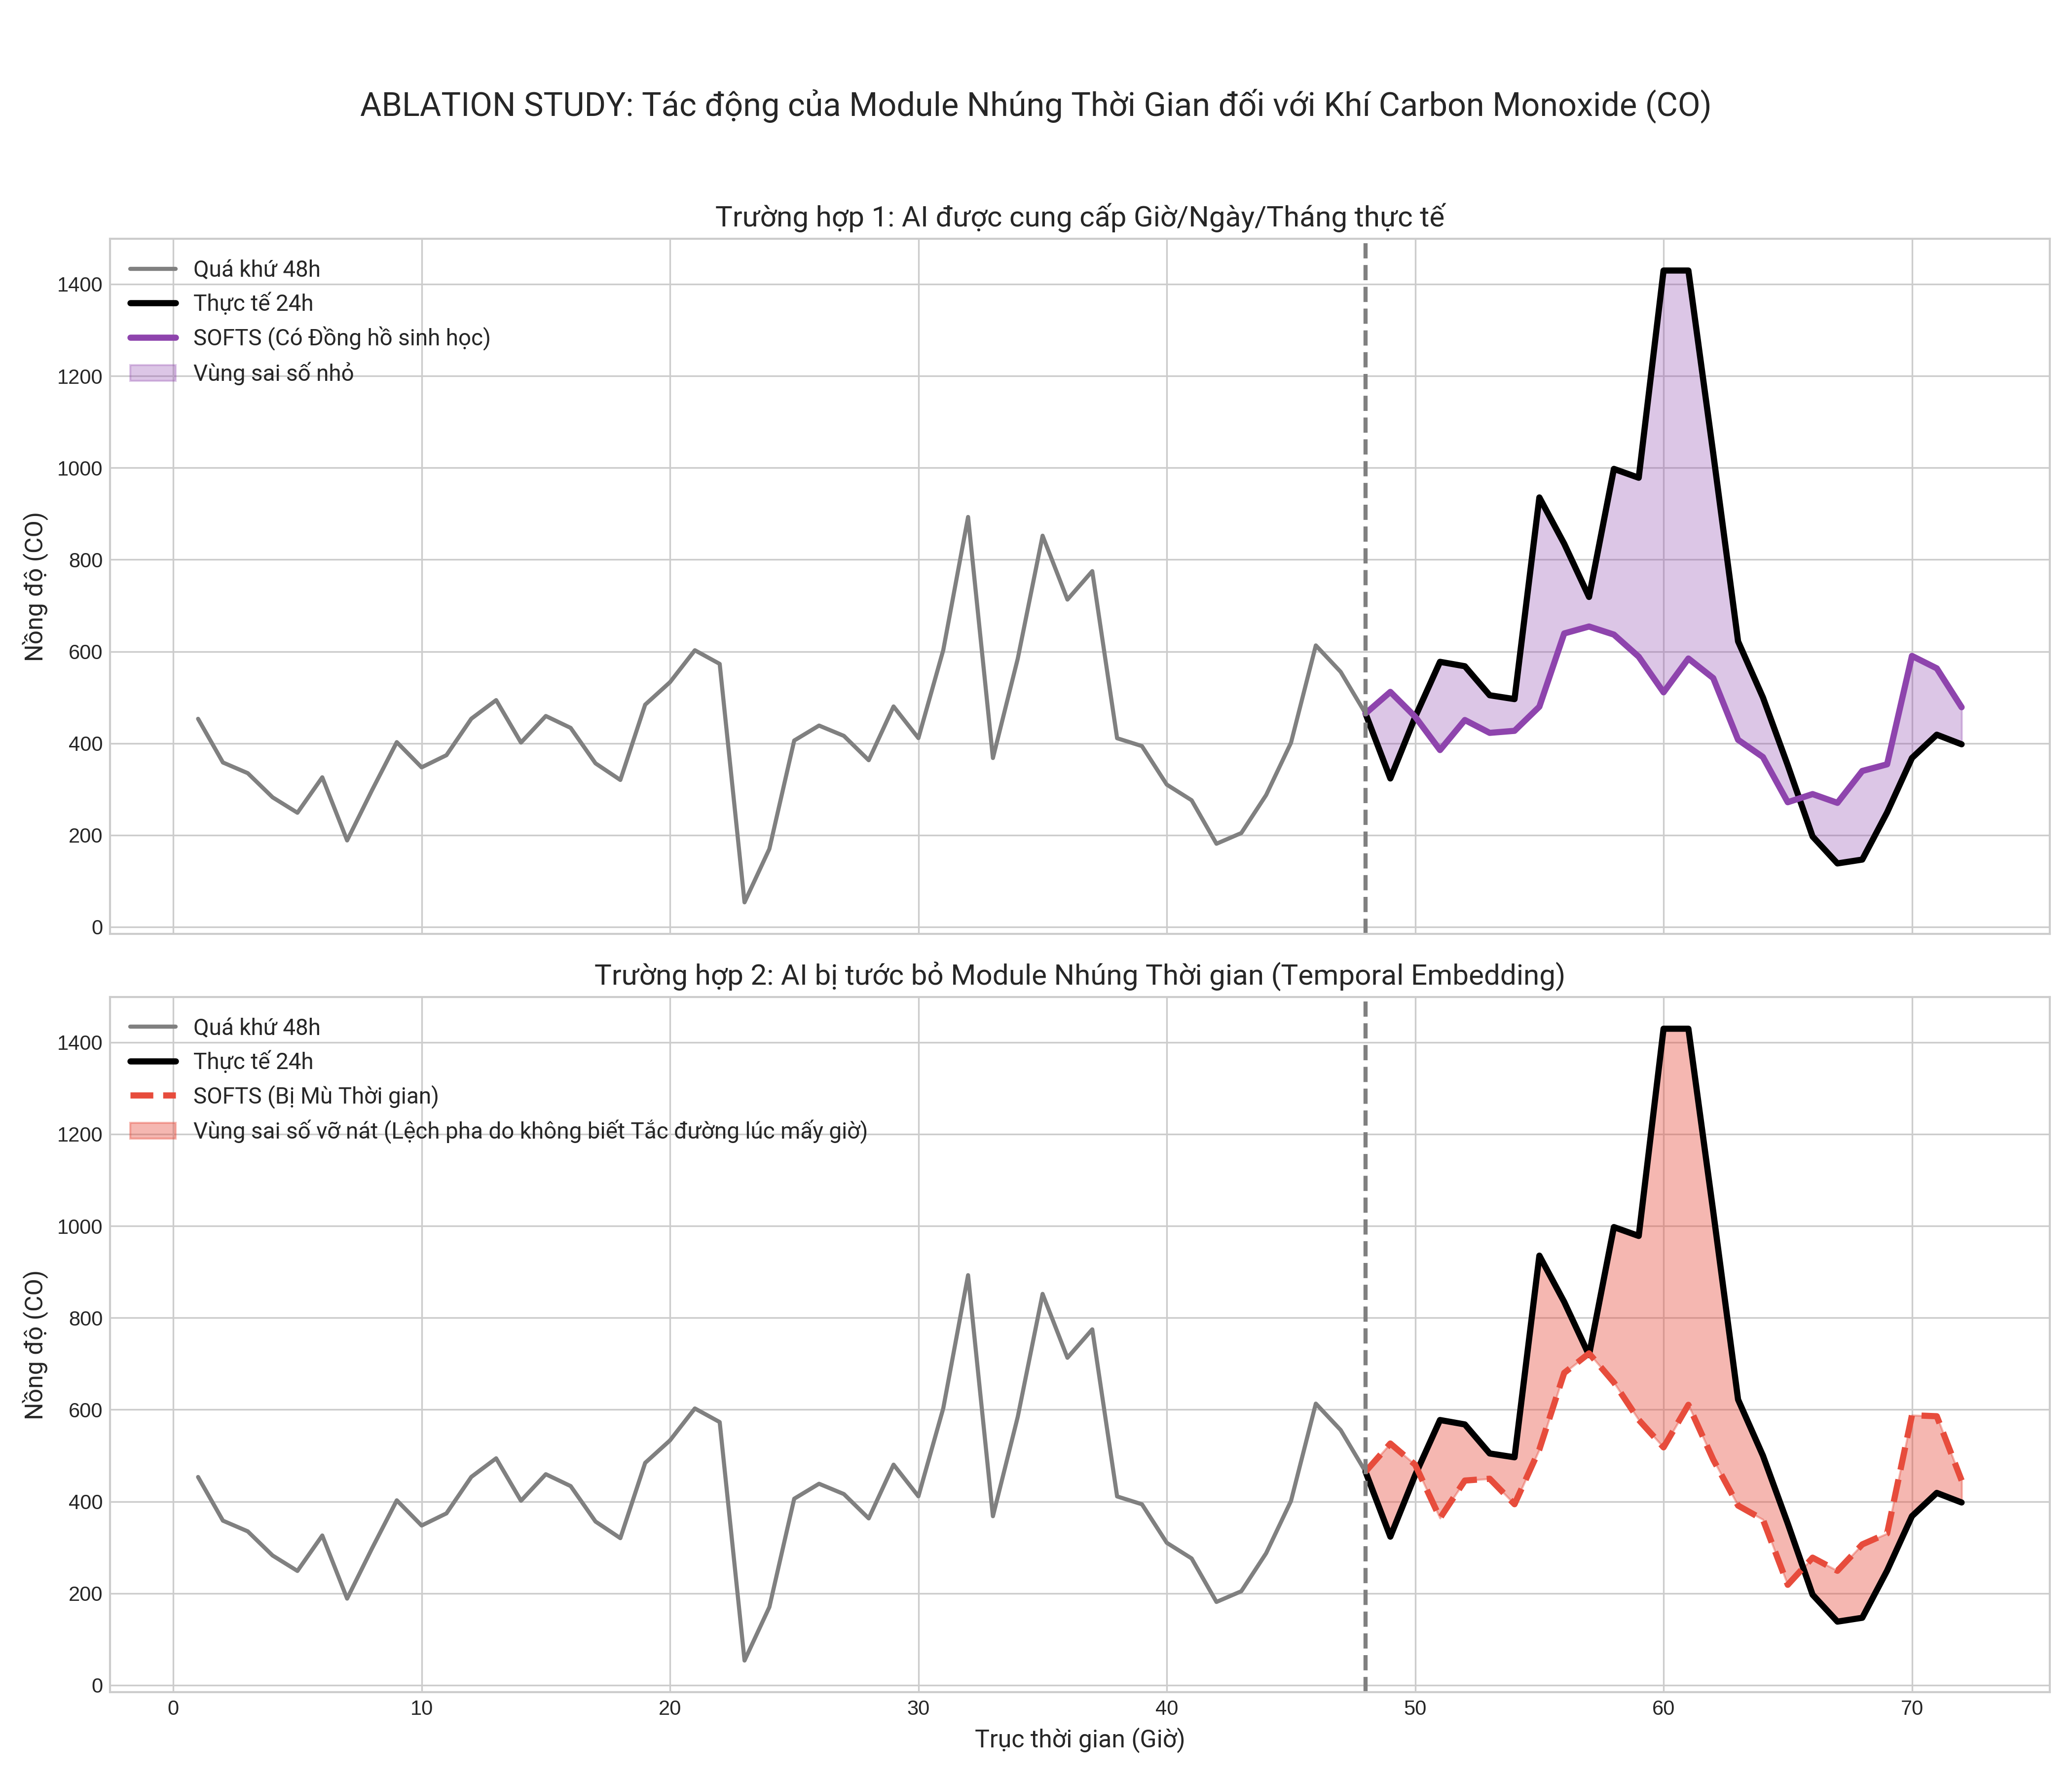

In [ ]:
!python /content/SOFTS/ablation_visualization_pro_time.py
from IPython.display import Image, display
display(Image('/content/SOFTS/Ablation_Time_Pro.png'))

In [ ]:
%%writefile /content/SOFTS/visualize_split.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request
from matplotlib import font_manager as fm

# ==========================================
# CÀI ĐẶT FONT CHUẨN
# ==========================================
font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path): urllib.request.urlretrieve(font_url, font_path)
vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')

# ==========================================
# ĐỌC DỮ LIỆU THẬT
# ==========================================
csv_path = '/content/SOFTS/dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv'
if not os.path.exists(csv_path):
    print(f"Lỗi: Không tìm thấy file {csv_path}")
else:
    df = pd.read_csv(csv_path)
    # Lấy biến CO để vẽ vì biểu đồ CO thể hiện chu kỳ rất đẹp
    data = df['co'].values
    total_length = len(data)
    time_steps = np.arange(total_length)

    # Chia tỷ lệ: 70% Train, 10% Val, 20% Test
    train_idx = int(total_length * 0.7)
    val_idx = int(total_length * 0.8)

    # ==========================================
    # VẼ BIỂU ĐỒ
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(15, 6))

    # Vẽ các vùng dữ liệu
    ax.plot(time_steps[:train_idx], data[:train_idx], color='#3498db', label=f'Train (70%) - {train_idx} giờ', linewidth=1)
    ax.plot(time_steps[train_idx:val_idx], data[train_idx:val_idx], color='#f39c12', label=f'Validation (10%) - {val_idx - train_idx} giờ', linewidth=1)
    ax.plot(time_steps[val_idx:], data[val_idx:], color='#2ecc71', label=f'Test (20%) - {total_length - val_idx} giờ', linewidth=1)

    # Vạch ngăn cách
    ax.axvline(x=train_idx, color='black', linestyle='--', linewidth=2)
    ax.axvline(x=val_idx, color='black', linestyle='--', linewidth=2)

    # Ghi chú Text
    y_max = np.max(data)
    ax.text(train_idx / 2, y_max * 1.05, 'Học Quy luật Hệ thống', fontproperties=vi_font, ha='center', color='#2980b9', weight='bold')
    ax.text((train_idx + val_idx) / 2, y_max * 1.05, 'Tinh chỉnh', fontproperties=vi_font, ha='center', color='#d35400', weight='bold')
    ax.text((val_idx + total_length) / 2, y_max * 1.05, 'Đánh giá Thực tế', fontproperties=vi_font, ha='center', color='#27ae60', weight='bold')

    ax.set_title(f'Chiến lược Chia tập Dữ liệu (Chronological Split) trên Bộ dữ liệu Hà Nội ({total_length} giờ)', fontproperties=vi_font_title, pad=25)
    ax.set_xlabel('Trục Thời gian Khách quan (Giờ)', fontproperties=vi_font)
    ax.set_ylabel('Nồng độ Khí CO', fontproperties=vi_font)
    ax.legend(loc='upper right', prop=vi_font, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('/content/SOFTS/Real_Dataset_Split.png', dpi=300)
    print("✅ Đã xuất ảnh Chia tập dữ liệu thành công!")

Writing /content/SOFTS/visualize_split.py


✅ Đã xuất ảnh Chia tập dữ liệu thành công!


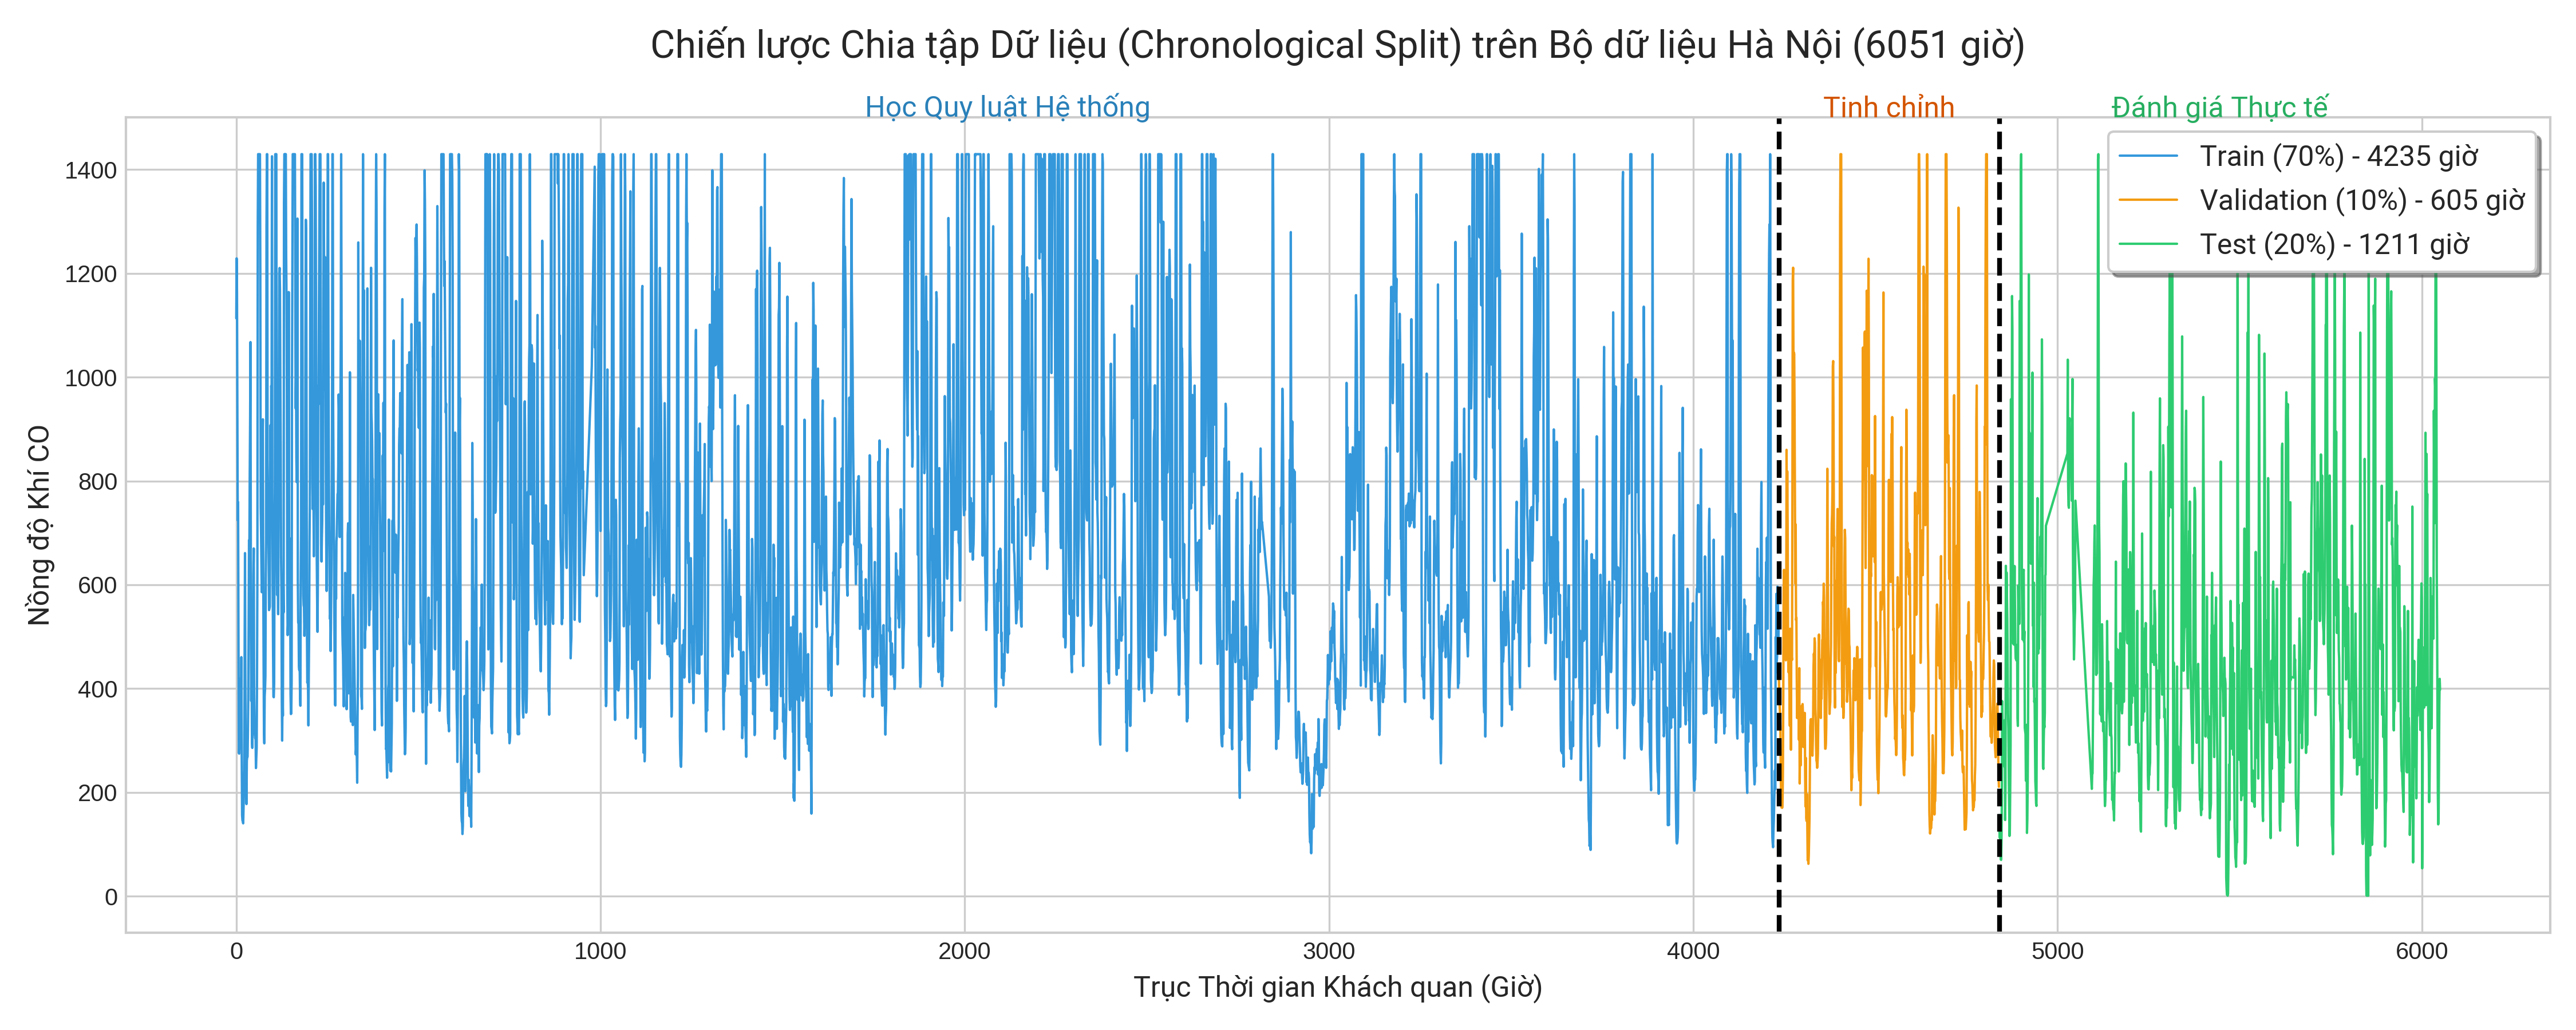

In [ ]:
!python /content/SOFTS/visualize_split.py
from IPython.display import Image, display
display(Image('/content/SOFTS/Real_Dataset_Split.png'))

In [ ]:
%%writefile /content/SOFTS/visualize_sliding_window.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import urllib.request
from matplotlib import font_manager as fm

font_url = 'https://fonts.gstatic.com/s/roboto/v30/KFOmCnqEu92Fr1Me5WZLCzYlKw.ttf'
font_path = '/content/SOFTS/Roboto-Regular.ttf'
if not os.path.exists(font_path): urllib.request.urlretrieve(font_url, font_path)
vi_font = fm.FontProperties(fname=font_path, size=12)
vi_font_title = fm.FontProperties(fname=font_path, size=16, weight='bold')
vi_font_small = fm.FontProperties(fname=font_path, size=11)

csv_path = '/content/SOFTS/dataset/Hanoi/Hanoi_AirQuality_Weather_7Vars_Dataset_Test2.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # Thiết lập tham số thực tế mô hình đang chạy
    seq_len = 192    # Quá khứ 192h
    pred_len = 24    # Tương lai 24h
    stride = 48      # Bước trượt (để 48h cho dễ nhìn trên hình)
    num_windows = 4  # Số lượng cửa sổ minh họa

    # Lấy 500 giờ đầu tiên của biến CO để minh họa
    display_len = 450
    data_subset = df['co'].values[:display_len]
    time_steps = np.arange(display_len)

    # Tạo Subplots: Phía trên là dữ liệu thật, phía dưới là mô hình khối
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [1, 1.5]}, figsize=(15, 9), sharex=True)

    # --- PHẦN TRÊN (AX1): ĐƯỜNG CONG DỮ LIỆU THẬT ---
    ax1.plot(time_steps, data_subset, color='#34495e', linewidth=2, label='Nồng độ Khí CO (Hà Nội)')
    ax1.set_title('Cơ chế tạo Batch Dữ liệu bằng Cửa sổ Trượt (Sliding Window)', fontproperties=vi_font_title, pad=15)
    ax1.set_ylabel('Nồng độ CO', fontproperties=vi_font)
    ax1.legend(loc='upper right', prop=vi_font)

    # --- PHẦN DƯỚI (AX2): SƠ ĐỒ KHỐI CỬA SỔ TRƯỢT ---
    ax2.set_ylim(0, num_windows + 1)
    ax2.axis('off') # Tắt viền trục y

    # Gióng trục ngang
    ax2.annotate('', xy=(display_len, 0.5), xytext=(0, 0.5), arrowprops=dict(arrowstyle="->", color='black', lw=2))
    ax2.text(display_len / 2, 0, 'Trục Thời gian (Giờ)', fontproperties=vi_font, ha='center', size=14)

    for i in range(num_windows):
        y_pos = num_windows - i  # Vẽ từ trên xuống dưới
        start_x = i * stride

        # Khối Input (Quá khứ - X) gióng thẳng lên đồ thị thật
        rect_x = patches.Rectangle((start_x, y_pos - 0.35), seq_len, 0.7,
                                   linewidth=1.5, edgecolor='black', facecolor='#3498db', alpha=0.8)
        ax2.add_patch(rect_x)
        ax2.text(start_x + seq_len/2, y_pos, f'Quá khứ: X (192h)',
                 fontproperties=vi_font_small, ha='center', va='center', color='white', weight='bold')

        # Khối Label (Tương lai - Y)
        rect_y = patches.Rectangle((start_x + seq_len, y_pos - 0.35), pred_len, 0.7,
                                   linewidth=1.5, edgecolor='black', facecolor='#e74c3c', alpha=0.8)
        ax2.add_patch(rect_y)
        ax2.text(start_x + seq_len + pred_len/2, y_pos, f'Y\n(24h)',
                 fontproperties=vi_font_small, ha='center', va='center', color='white', weight='bold')

        # Tên Mẫu (Sample)
        ax2.text(-10, y_pos, f'Mẫu {i+1}\n(Batch)', fontproperties=vi_font, ha='right', va='center', weight='bold')

        # Vẽ đường gióng nét đứt mờ từ khối Lên Đồ thị gốc để thấy sự liên kết
        ax1.axvline(x=start_x, color='gray', linestyle=':', alpha=0.3)
        ax1.axvline(x=start_x + seq_len, color='#3498db', linestyle=':', alpha=0.5)
        ax1.axvline(x=start_x + seq_len + pred_len, color='#e74c3c', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig('/content/SOFTS/Real_Sliding_Window.png', dpi=300)
    print("✅ Đã xuất ảnh Cửa sổ Trượt thành công!")

Writing /content/SOFTS/visualize_sliding_window.py


✅ Đã xuất ảnh Cửa sổ Trượt thành công!


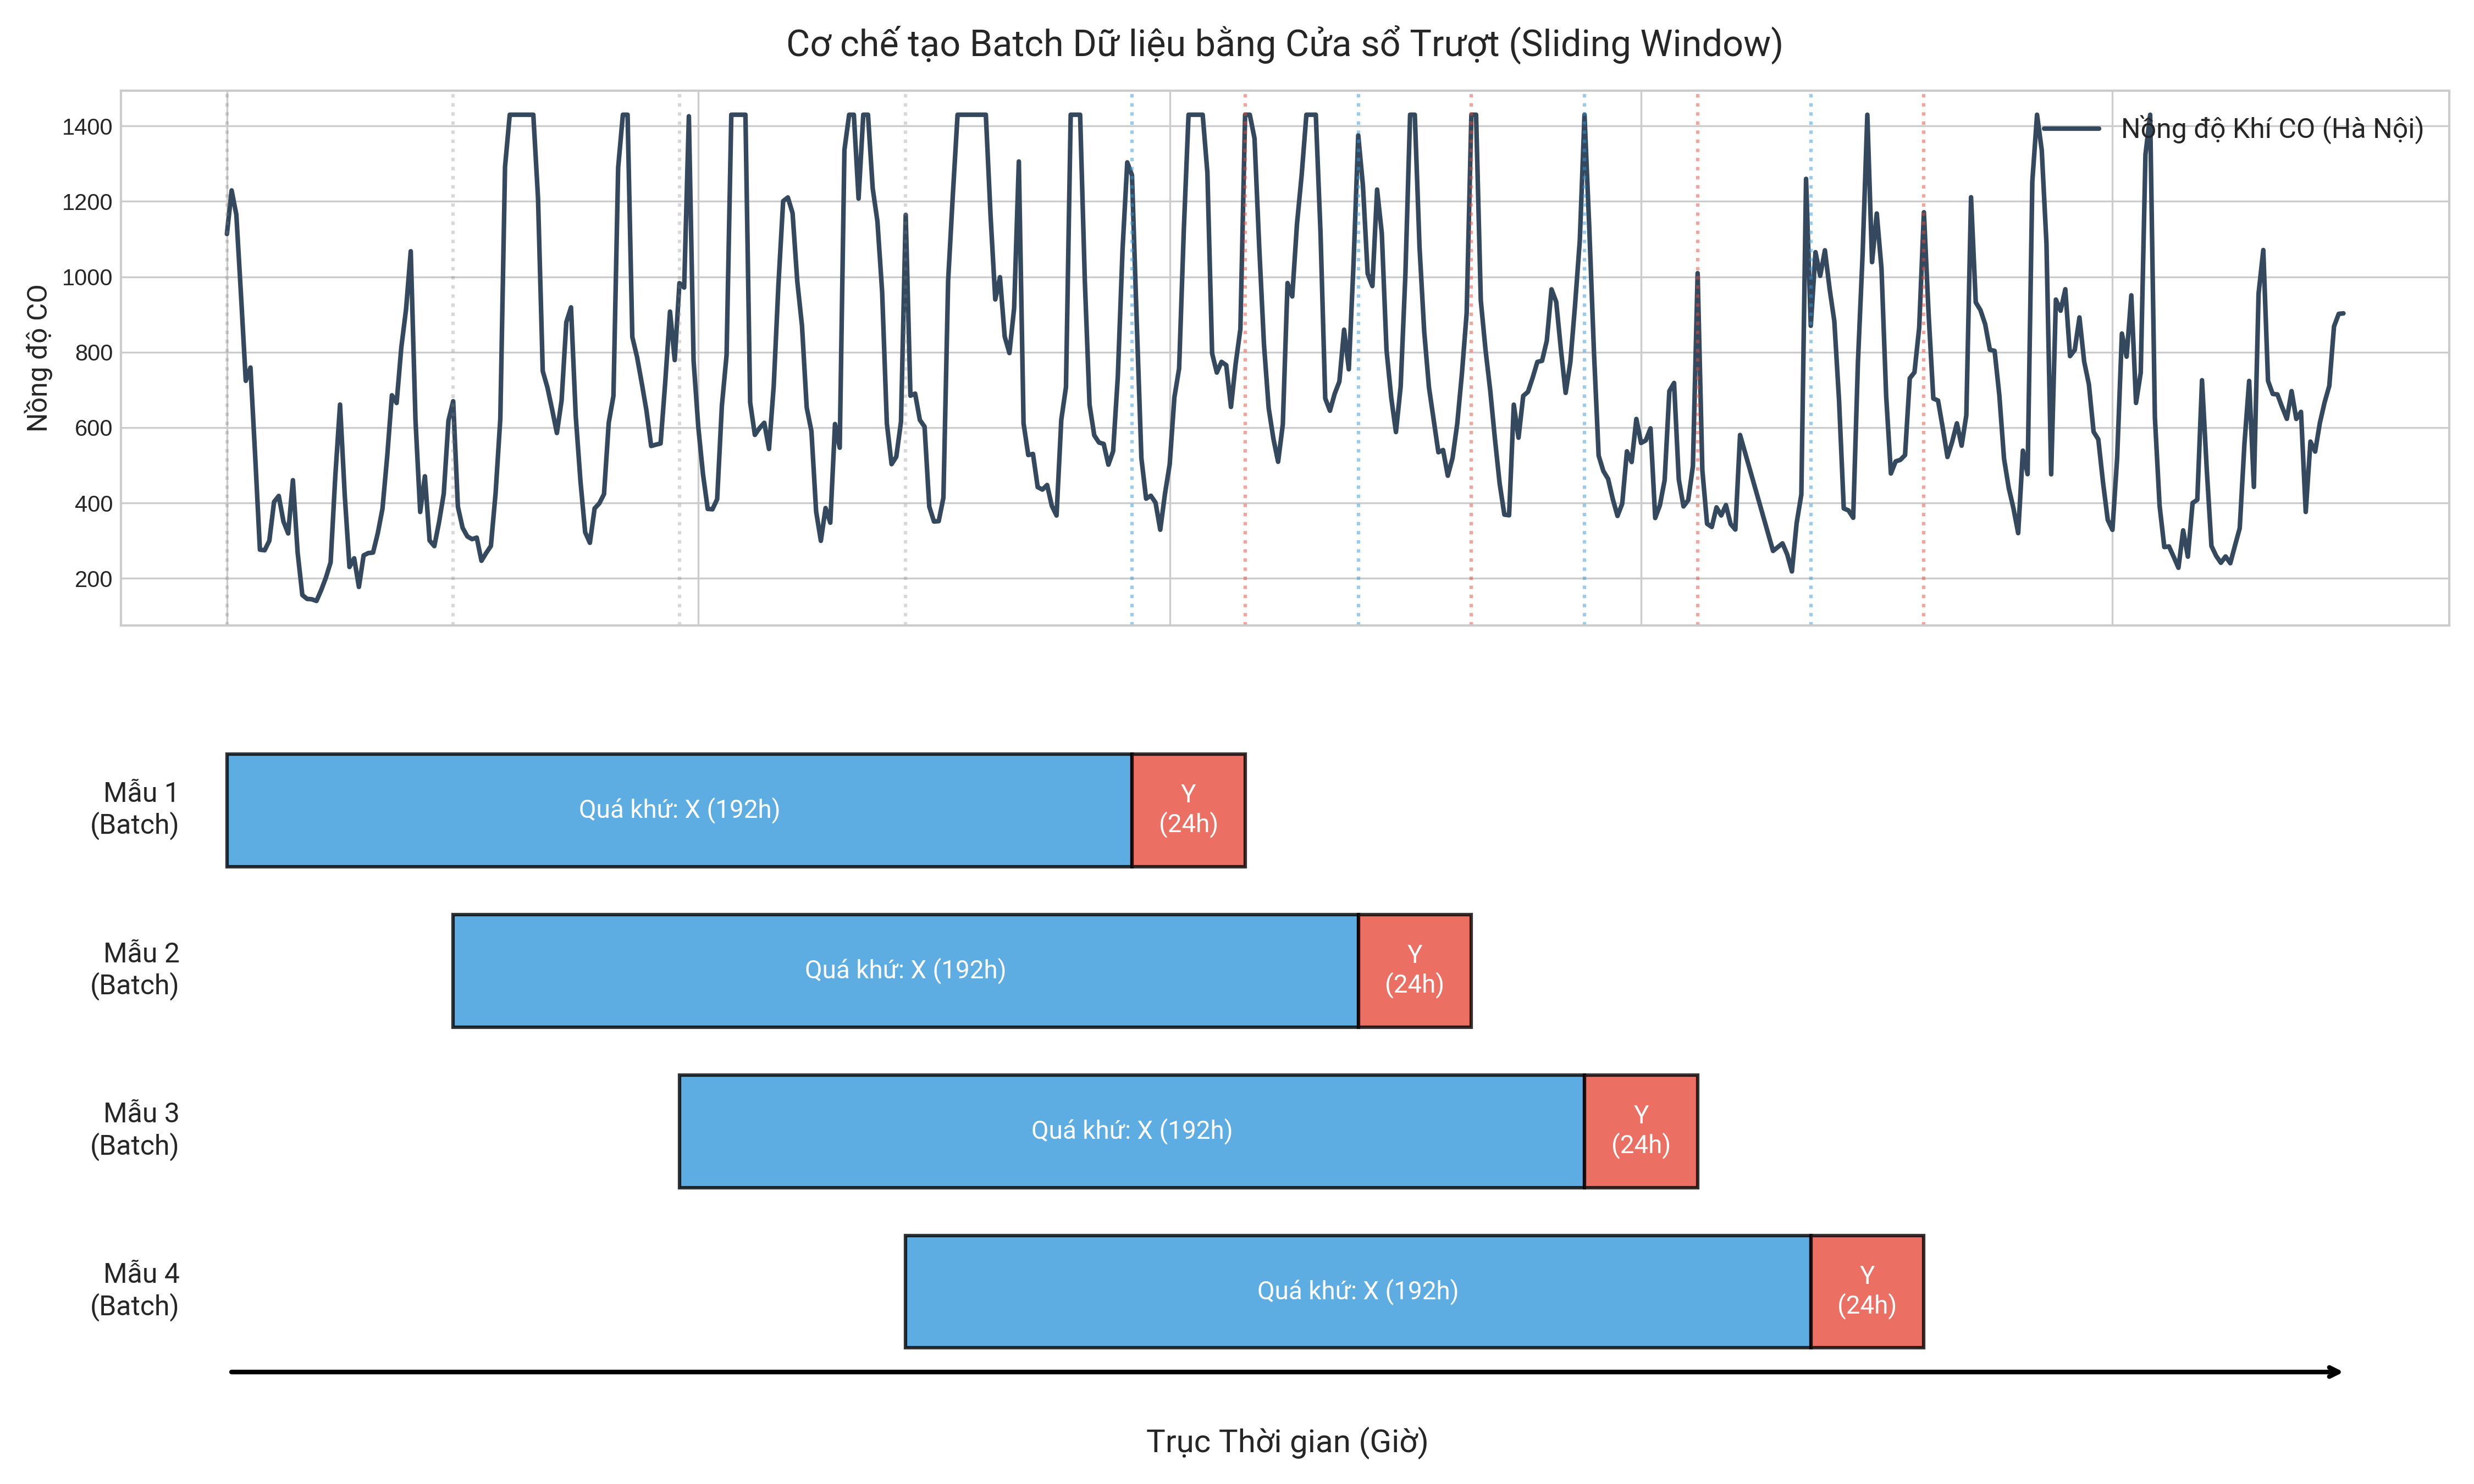

In [ ]:
!python /content/SOFTS/visualize_sliding_window.py
from IPython.display import Image, display
display(Image('/content/SOFTS/Real_Sliding_Window.png'))